# 🔍 Exploratory Data Analysis — Complex Multi-Table Database

Notebook này thực hiện EDA toàn diện trên database gồm **13 bảng** với các mối quan hệ phức tạp.

**Nội dung:**
1. Kết nối & khám phá schema
2. Thống kê tổng quan từng bảng
3. Phân tích chất lượng dữ liệu (null, duplicate, outlier)
4. Phân tích phân phối & thống kê mô tả
5. Phân tích mối quan hệ giữa các bảng (FK integrity)
6. Correlation & feature analysis
7. Visualizations tổng hợp

---
## 0. Setup & Dependencies

In [3]:
# ── Cài đặt nếu chưa có ──────────────────────────────────────────────────
# !pip install duckdb pandas numpy matplotlib seaborn plotly missingno networkx

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import missingno as msno
import networkx as nx
# from IPython.display import display, HTML

import sys
import os
sys.path.append(os.path.abspath('..'))
from src.connection import get_connection

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_colwidth', 60)

# Matplotlib style
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_palette('Set2')

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


---
## 1. Kết nối Database

In [4]:
# ── Kết nối ──────────────────────────────────────────────────────────────
con = get_connection()   # <-- hàm của bạn

# Helper: chạy SQL → DataFrame
def q(sql: str) -> pd.DataFrame:
    return con.execute(sql).df()

print('✅ Connected to database')

✅ Connected to database


---
## 2. Khám phá Schema — Danh sách bảng & cột

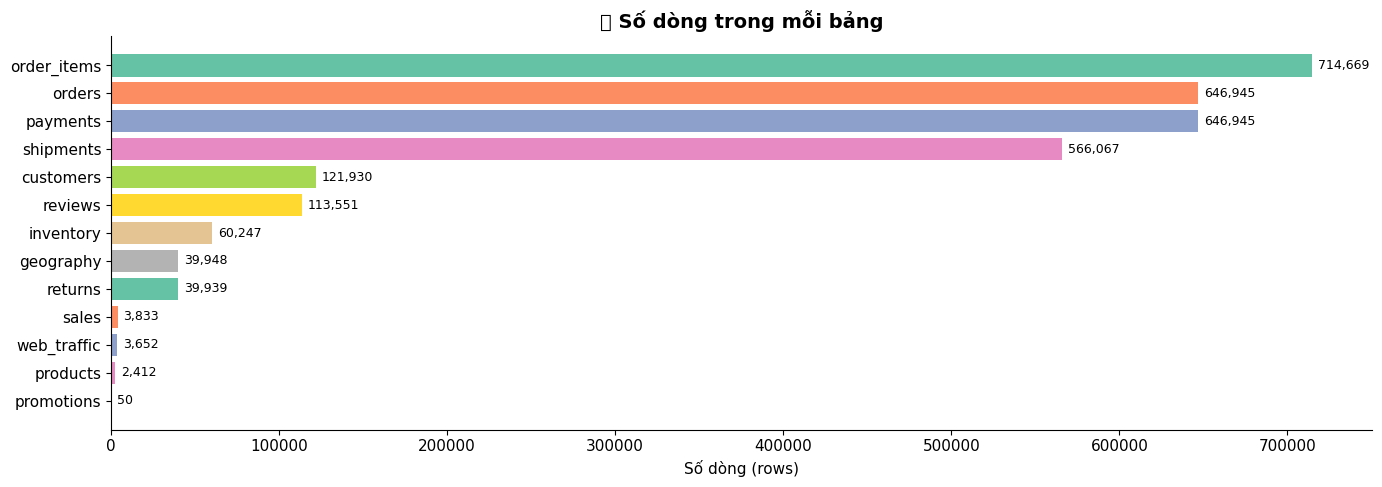

In [ ]:
# ── Bar chart số dòng từng bảng ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
sorted_rc = sorted(row_counts.items(), key=lambda x: x[1], reverse=True)
tbls, cnts = zip(*sorted_rc)

bars = ax.barh(tbls, cnts, color=sns.color_palette('Set2', len(tbls)))
for bar, cnt in zip(bars, cnts):
    ax.text(cnt + max(cnts) * 0.005, bar.get_y() + bar.get_height()/2,
            f'{cnt:,}', va='center', fontsize=9)

ax.set_xlabel('Số dòng (rows)')
ax.set_title('🗂️ Số dòng trong mỗi bảng', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 3. Thống kê mô tả từng bảng

In [10]:
# ── Hàm thống kê cho 1 bảng ──────────────────────────────────────────────
def describe_table(table_name: str, sample: int = 50_000) -> dict:
    """Trả về dict gồm: df mẫu, describe, null report, duplicate count."""
    df = q(f'SELECT * FROM "{table_name}" LIMIT {sample}')
    n_total = row_counts.get(table_name, len(df))

    # Null report
    null_report = pd.DataFrame({
        'column': df.columns,
        'dtype': df.dtypes.values,
        'null_count': df.isnull().sum().values,
        'null_pct': (df.isnull().mean() * 100).round(2).values,
        'unique_count': df.nunique().values,
        'unique_pct': (df.nunique() / max(len(df), 1) * 100).round(2).values,
    })

    # Duplicates
    dup_count = df.duplicated().sum()

    return {
        'df': df,
        'n_total': n_total,
        'describe': df.describe(include='all').T,
        'null_report': null_report,
        'dup_count': dup_count,
    }

print('✅ describe_table() ready')

✅ describe_table() ready


In [11]:
# ── Chạy cho tất cả bảng ─────────────────────────────────────────────────
table_stats = {}
for tbl in TABLES:
    print(f'  Analyzing: {tbl} ...', end='\r')
    try:
        table_stats[tbl] = describe_table(tbl)
    except Exception as e:
        print(f'  ⚠️  {tbl}: {e}')

print('\n✅ Done analyzing all tables')

  Analyzing: web_traffic ...
✅ Done analyzing all tables


In [12]:
# ── Hiển thị chi tiết từng bảng ──────────────────────────────────────────
for tbl, stats in table_stats.items():
    df = stats['df']
    nr = stats['null_report']
    dup = stats['dup_count']
    n = stats['n_total']

    print('\n' + '='*70)
    print(f'  📁  TABLE: {tbl.upper()}   ({n:,} rows × {len(df.columns)} cols)')
    print('='*70)

    print(f'\n🔍 Sample (first 3 rows):')
    display(df.head(3))

    print(f'\n📊 Null & Cardinality Report  |  Duplicates: {dup:,}')
    styled = (
        nr.sort_values('null_pct', ascending=False)
        .style.background_gradient(subset=['null_pct'], cmap='Oranges')
              .background_gradient(subset=['unique_pct'], cmap='Greens')
    )
    display(styled)

    print('\n📈 Descriptive Statistics:')
    display(stats['describe'])


  📁  TABLE: CUSTOMERS   (121,930 rows × 7 cols)

🔍 Sample (first 3 rows):


,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search



📊 Null & Cardinality Report  |  Duplicates: 0


,column,dtype,null_count,null_pct,unique_count,unique_pct
0,customer_id,int32,0,0.000000,50000,100.000000
1,zip,int32,0,0.000000,12906,25.810000
2,city,str,0,0.000000,14,0.030000
3,signup_date,datetime64[us],0,0.000000,3842,7.680000
4,gender,str,0,0.000000,3,0.010000
5,age_group,str,0,0.000000,5,0.010000
6,acquisition_channel,str,0,0.000000,6,0.010000



📈 Descriptive Statistics:


...

,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source
0,2013-01-01,9760,7253,39093,0.01,102.90,organic_search
1,2013-01-02,10456,8151,47611,0.00,120.50,organic_search
2,2013-01-03,10076,7458,36963,0.00,263.60,direct



📊 Null & Cardinality Report  |  Duplicates: 0


,column,dtype,null_count,null_pct,unique_count,unique_pct
0,date,datetime64[us],0,0.000000,3652,100.000000
1,sessions,int32,0,0.000000,3447,94.390000
2,unique_visitors,int32,0,0.000000,3382,92.610000
3,page_views,int32,0,0.000000,3620,99.120000
4,bounce_rate,float64,0,0.000000,4,0.110000
5,avg_session_duration_sec,float64,0,0.000000,1771,48.490000
6,traffic_source,str,0,0.000000,6,0.160000



📈 Descriptive Statistics:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,3652,NaN,NaN,NaN,2017-12-31 12:00:00,2013-01-01 00:00:00,2015-07-02 18:00:00,2017-12-31 12:00:00,2020-07-01 06:00:00,2022-12-31 00:00:00,NaN
sessions,"3,652.00",NaN,NaN,NaN,"25,041.77","7,973.00","17,099.25","23,633.50","31,782.75","50,947.00","9,422.61"
unique_visitors,"3,652.00",NaN,NaN,NaN,"19,031.40","6,136.00","12,915.00","17,924.00","24,191.75","40,430.00","7,237.95"
page_views,"3,652.00",NaN,NaN,NaN,"108,615.22","30,451.00","72,982.00","101,010.50","138,086.00","275,560.00","44,472.06"
bounce_rate,"3,652.00",NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.01,0.01,0.00
avg_session_duration_sec,"3,652.00",NaN,NaN,NaN,210.28,100.10,156.70,209.20,266.20,319.90,63.77
traffic_source,3652,6,organic_search,1090,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 4. Phân tích chất lượng dữ liệu tổng hợp

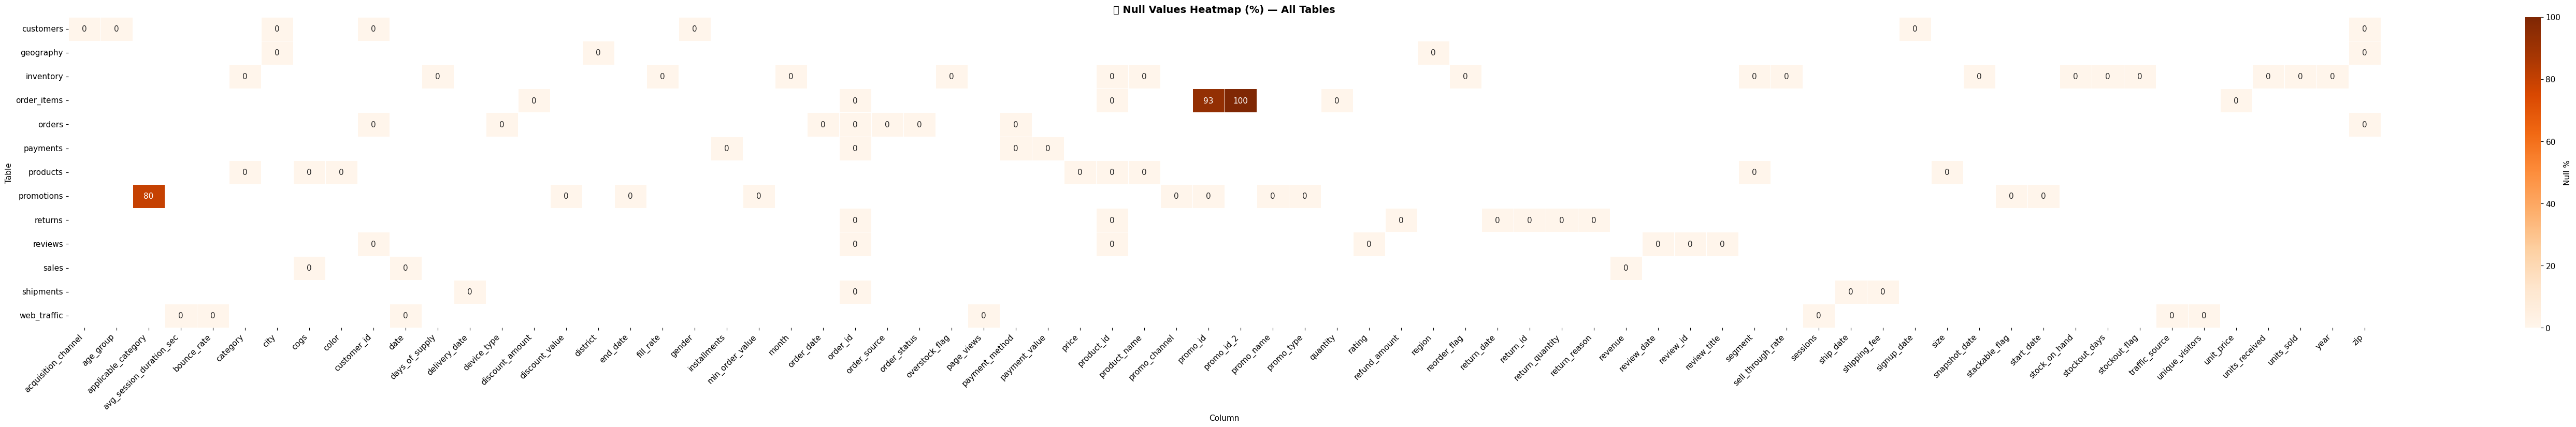

In [ ]:
# ── Heatmap null values tổng hợp ─────────────────────────────────────────
null_matrix = pd.DataFrame({
    tbl: stats['null_report'].set_index('column')['null_pct']
    for tbl, stats in table_stats.items()
}).T

fig, ax = plt.subplots(figsize=(max(16, len(null_matrix.columns)), max(6, len(TABLES) * 0.6)))
sns.heatmap(
    null_matrix, annot=True, fmt='.0f', cmap='Oranges',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Null %'}
)
ax.set_title('🚨 Null Values Heatmap (%) — All Tables', fontsize=14, fontweight='bold')
ax.set_xlabel('Column')
ax.set_ylabel('Table')
plt.xticks(rotation=45, ha='right')
plt.show()

In [15]:
# ── Duplicate summary ────────────────────────────────────────────────────
dup_df = pd.DataFrame([
    {'table': tbl, 'duplicates': stats['dup_count'],
     'total_rows': stats['n_total'],
     'dup_pct': round(stats['dup_count'] / max(len(stats['df']), 1) * 100, 2)}
    for tbl, stats in table_stats.items()
]).sort_values('dup_pct', ascending=False)

print('🔁 Duplicate Analysis:')
display(dup_df.style.background_gradient(subset=['dup_pct'], cmap='Reds'))

🔁 Duplicate Analysis:


,table,duplicates,total_rows,dup_pct
0,customers,0,121930,0.000000
1,geography,0,39948,0.000000
2,inventory,0,60247,0.000000
3,order_items,0,714669,0.000000
4,orders,0,646945,0.000000
5,payments,0,646945,0.000000
6,products,0,2412,0.000000
7,promotions,0,50,0.000000
8,returns,0,39939,0.000000
9,reviews,0,113551,0.000000


📊 Missing value pattern — order_items (highest avg null%)


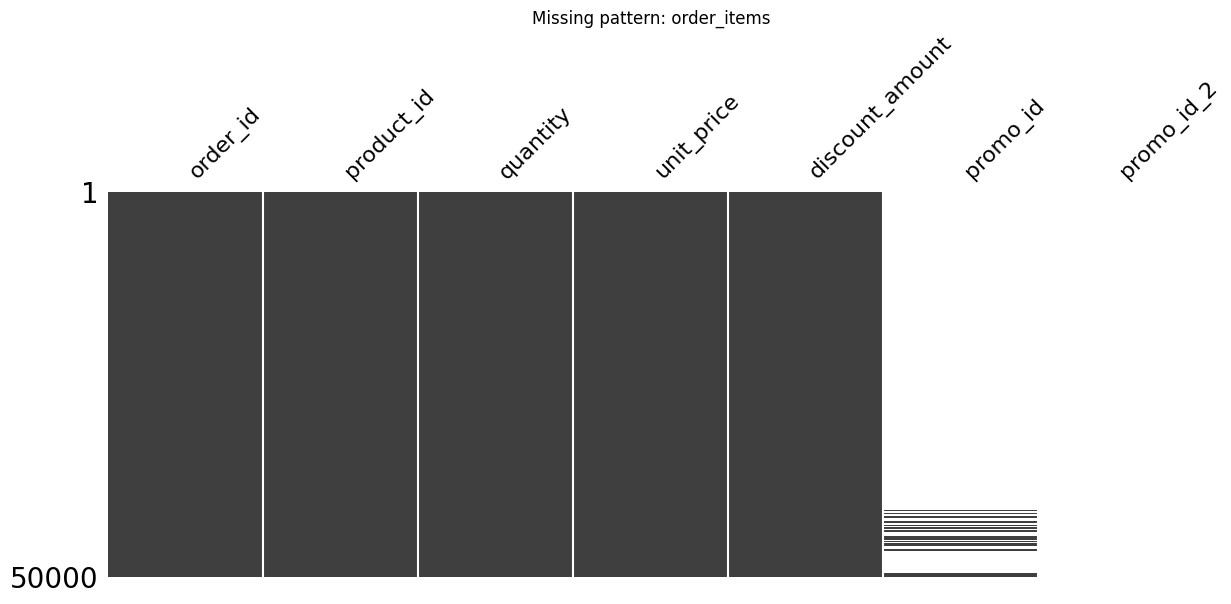

In [16]:
# ── Missingno matrix cho bảng có nhiều null nhất ─────────────────────────
most_null_tbl = (
    pd.DataFrame([{'table': t, 'avg_null': s['null_report']['null_pct'].mean()}
                  for t, s in table_stats.items()])
    .sort_values('avg_null', ascending=False)['table'].iloc[0]
)

print(f'📊 Missing value pattern — {most_null_tbl} (highest avg null%)')
msno.matrix(table_stats[most_null_tbl]['df'], figsize=(14, 5), sparkline=False)
plt.title(f'Missing pattern: {most_null_tbl}', fontsize=12)
plt.show()

---
## 5. Phân tích phân phối (Numeric & Categorical)

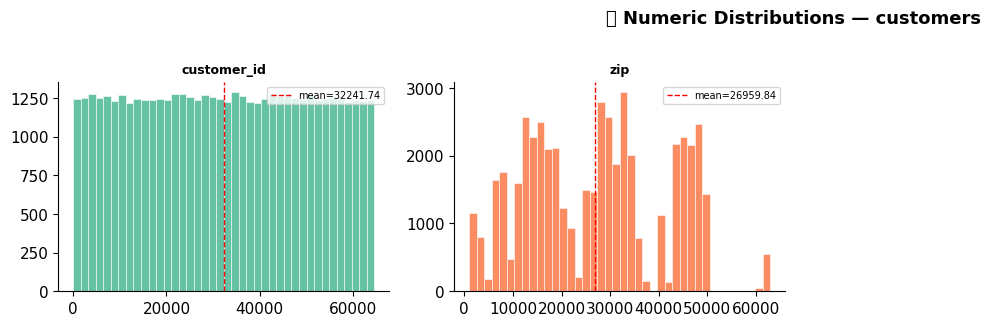

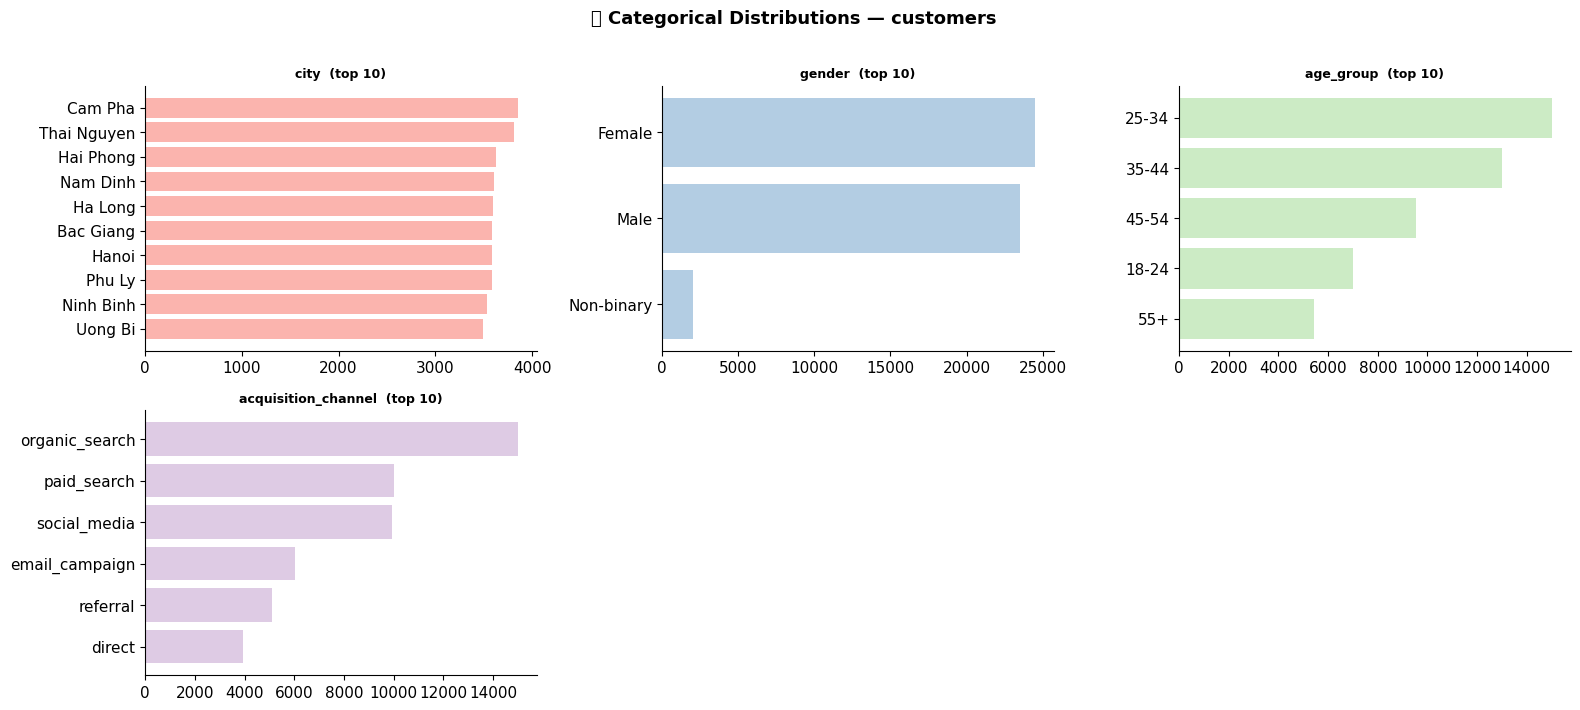

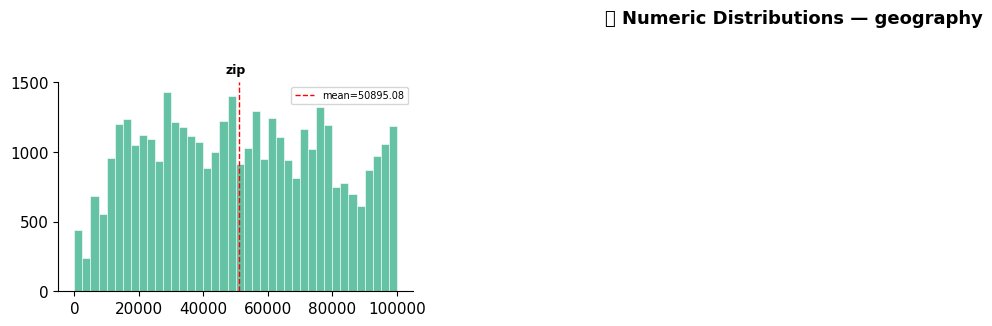

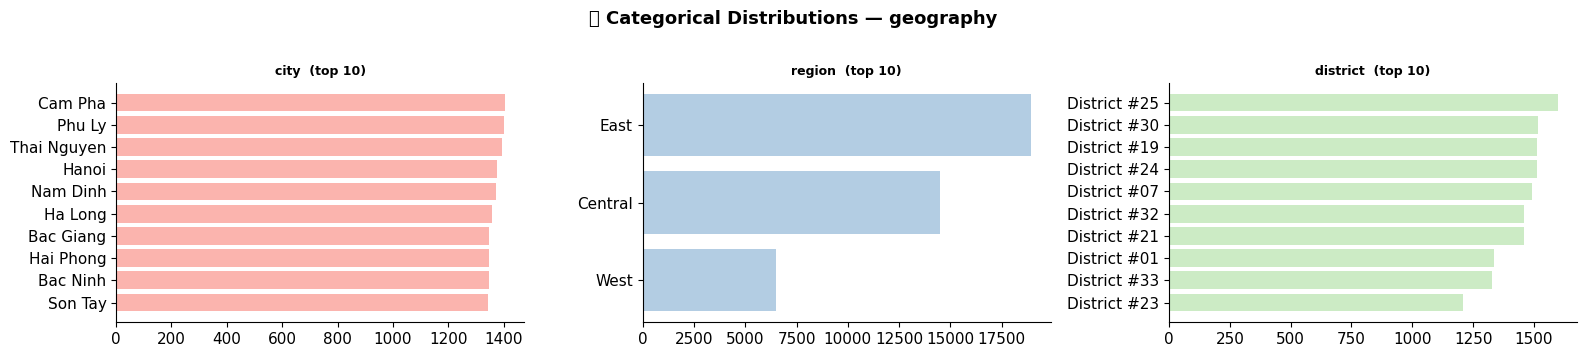

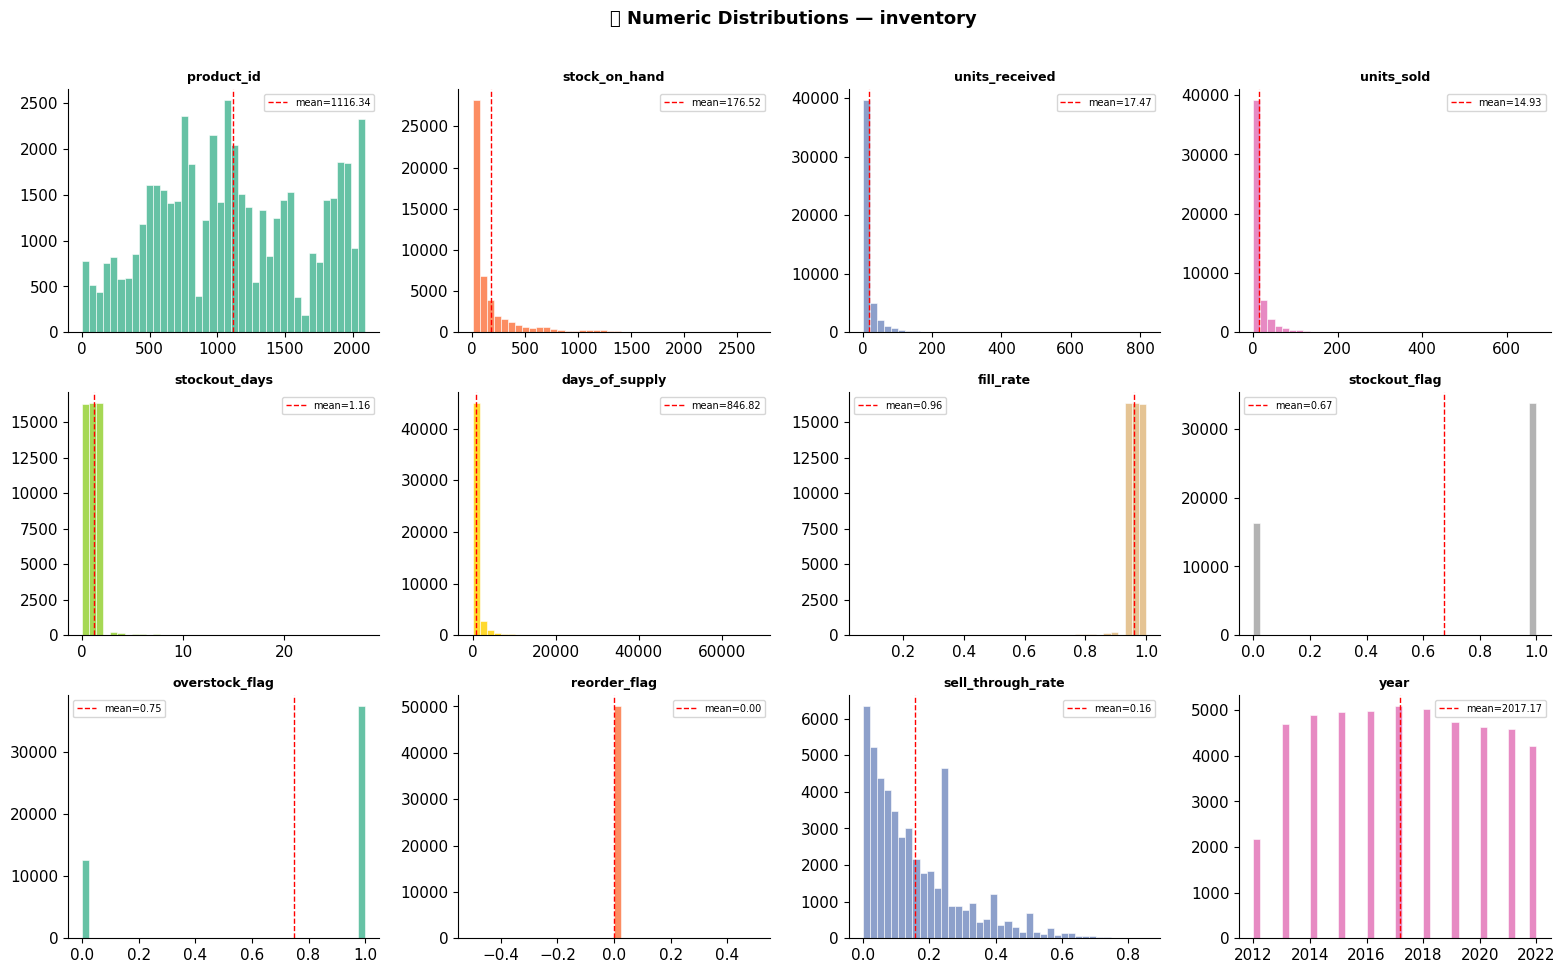

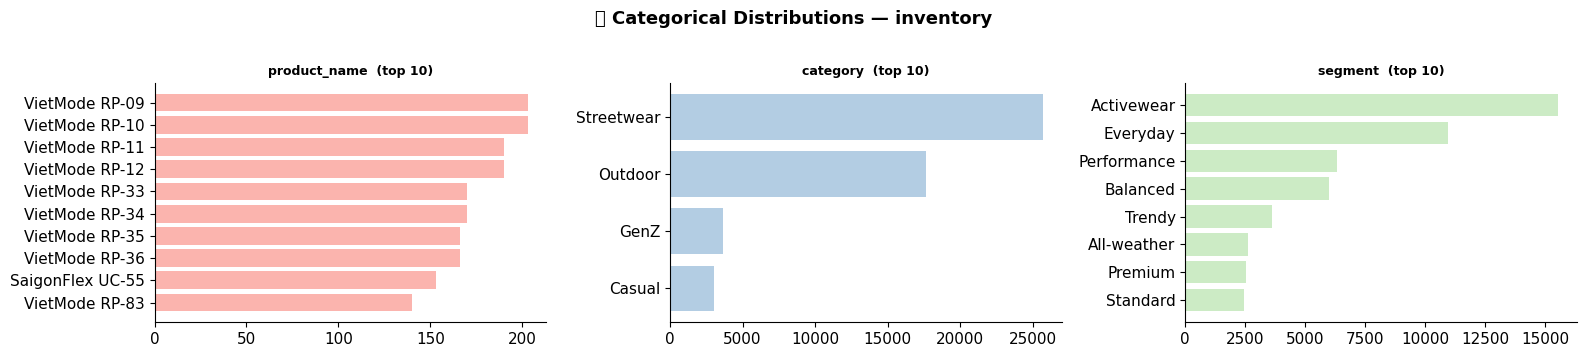

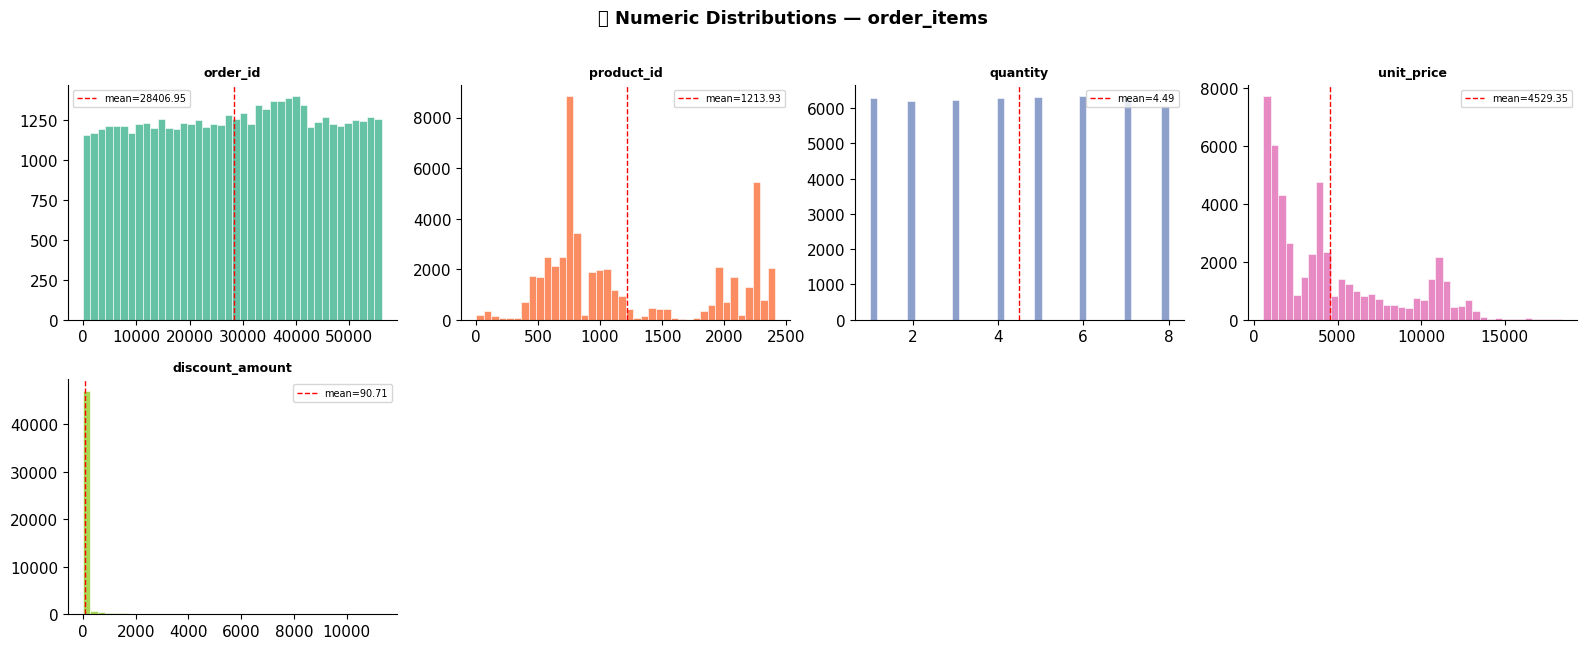

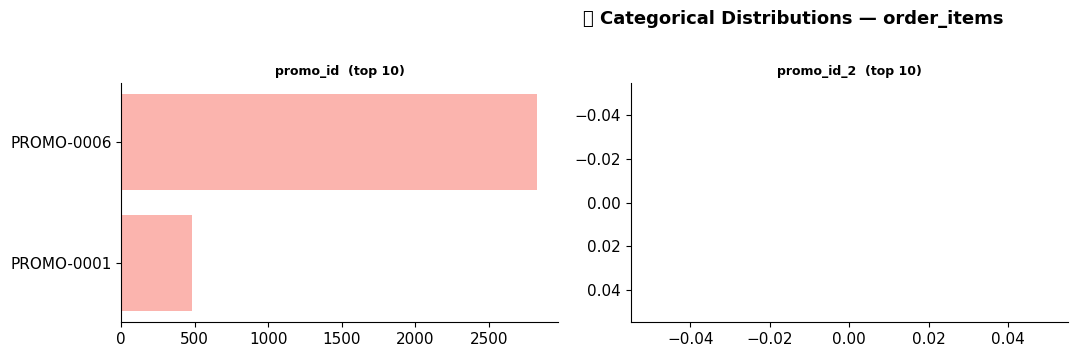

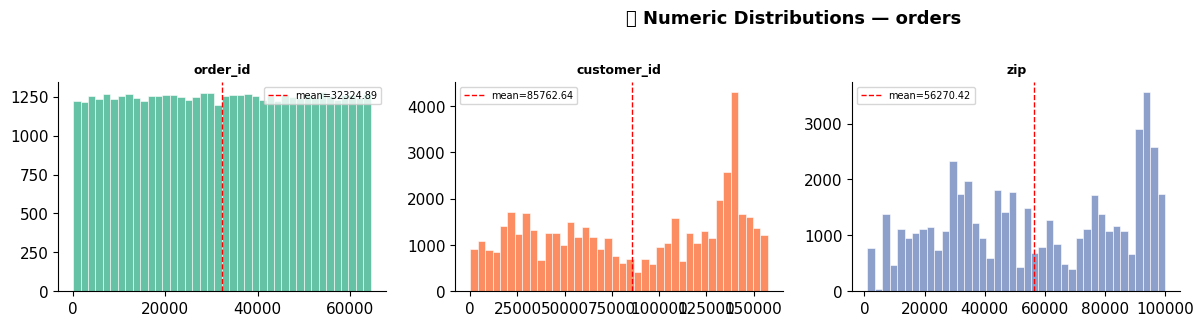

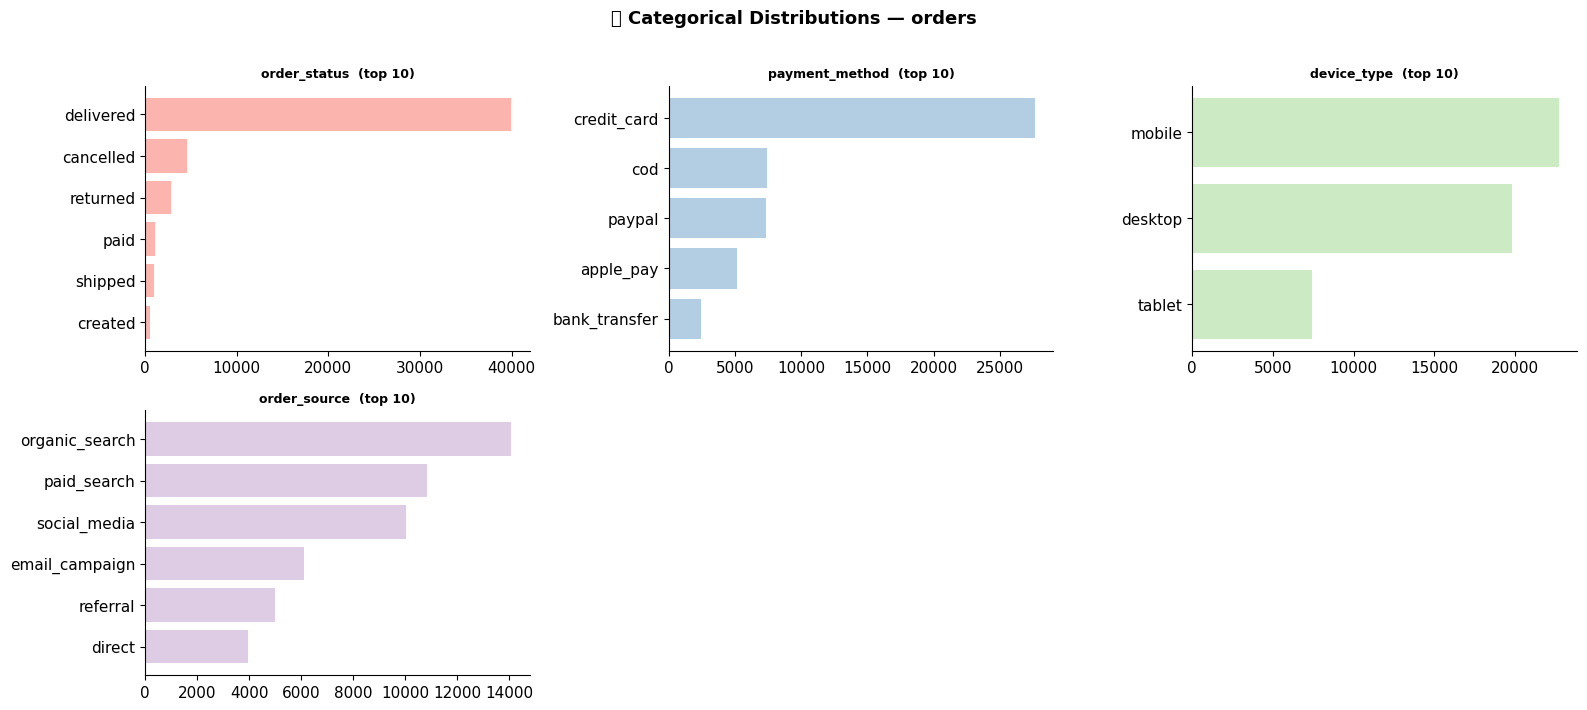

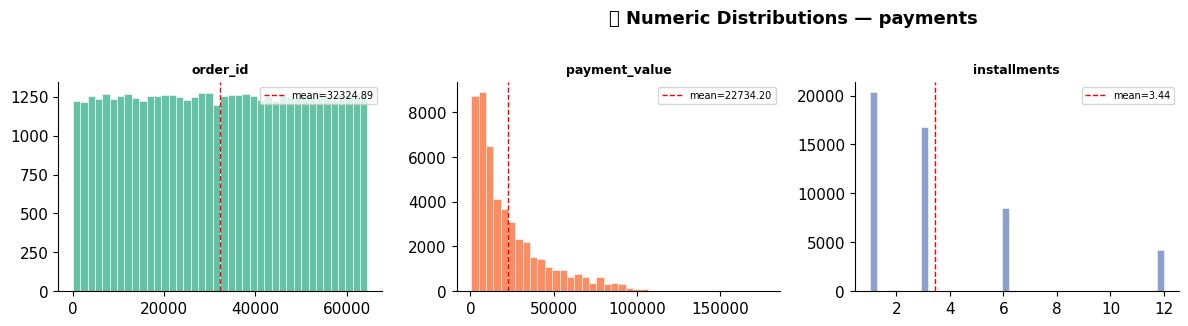

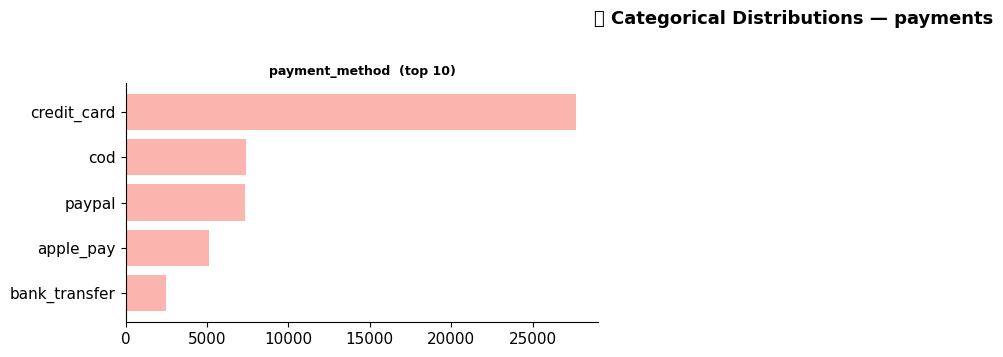

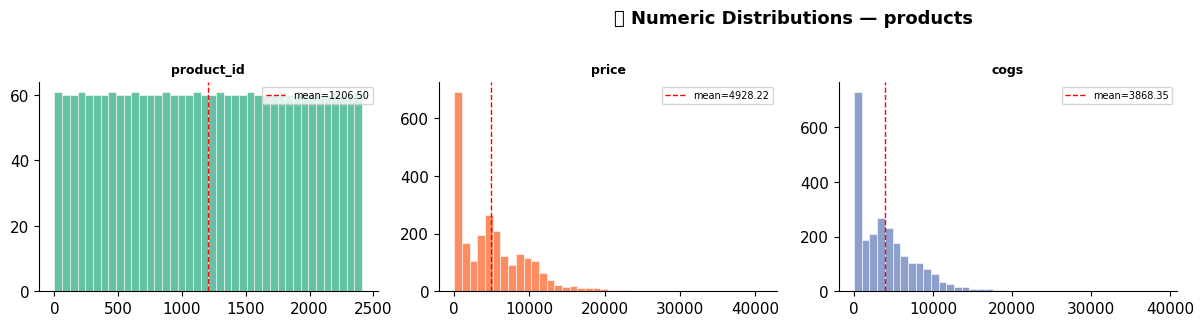

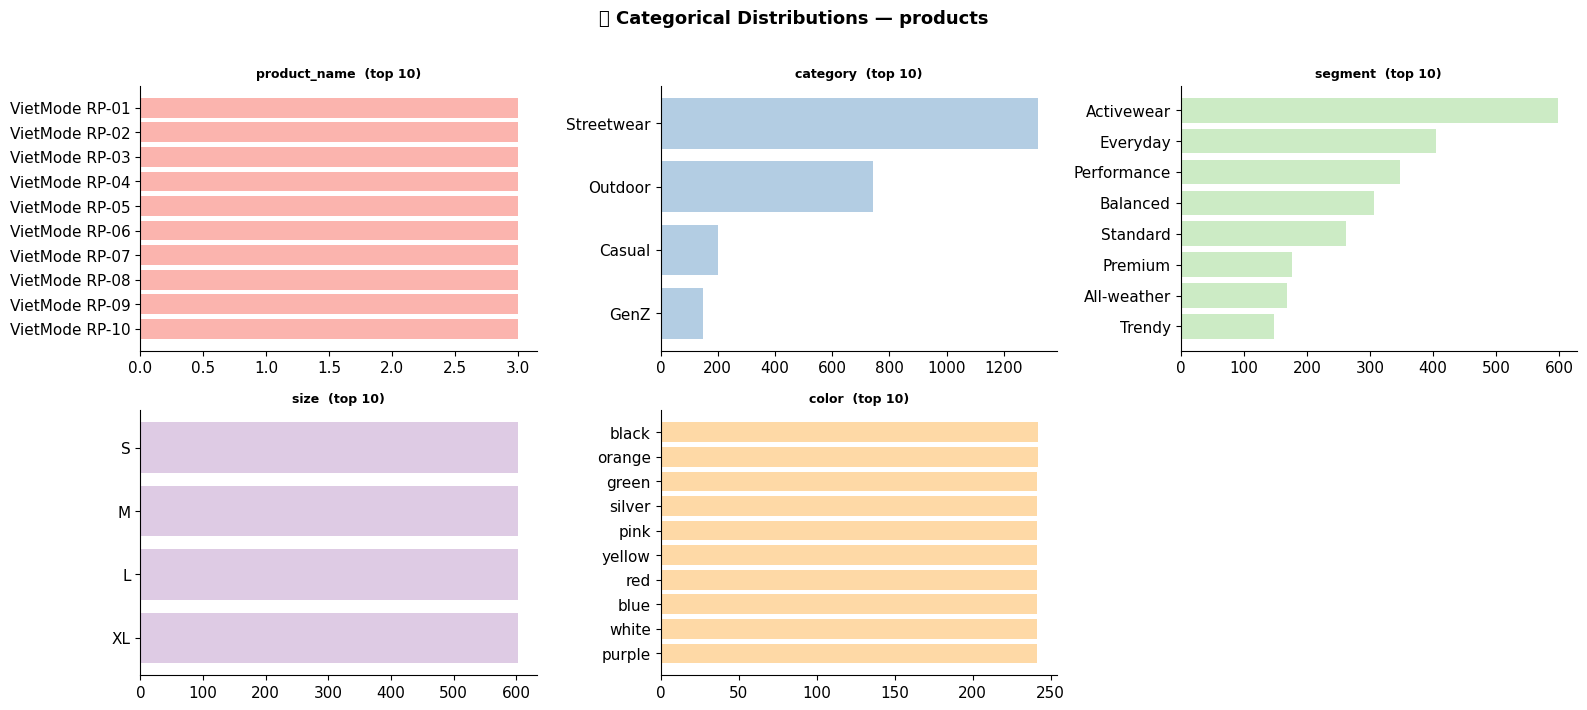

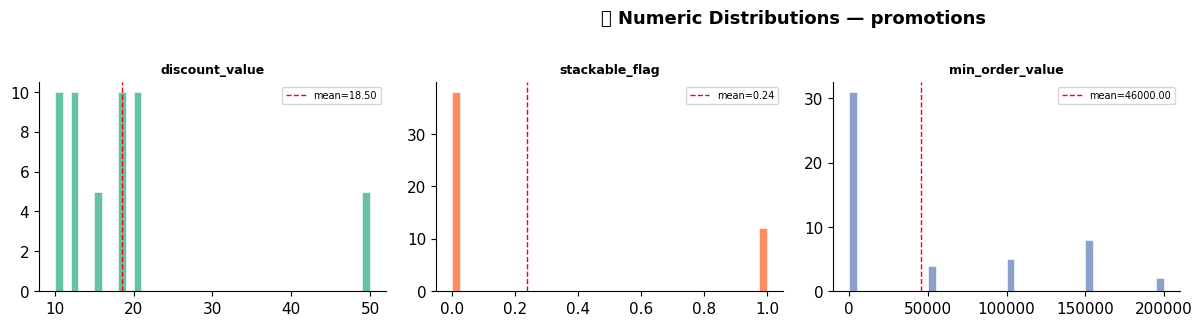

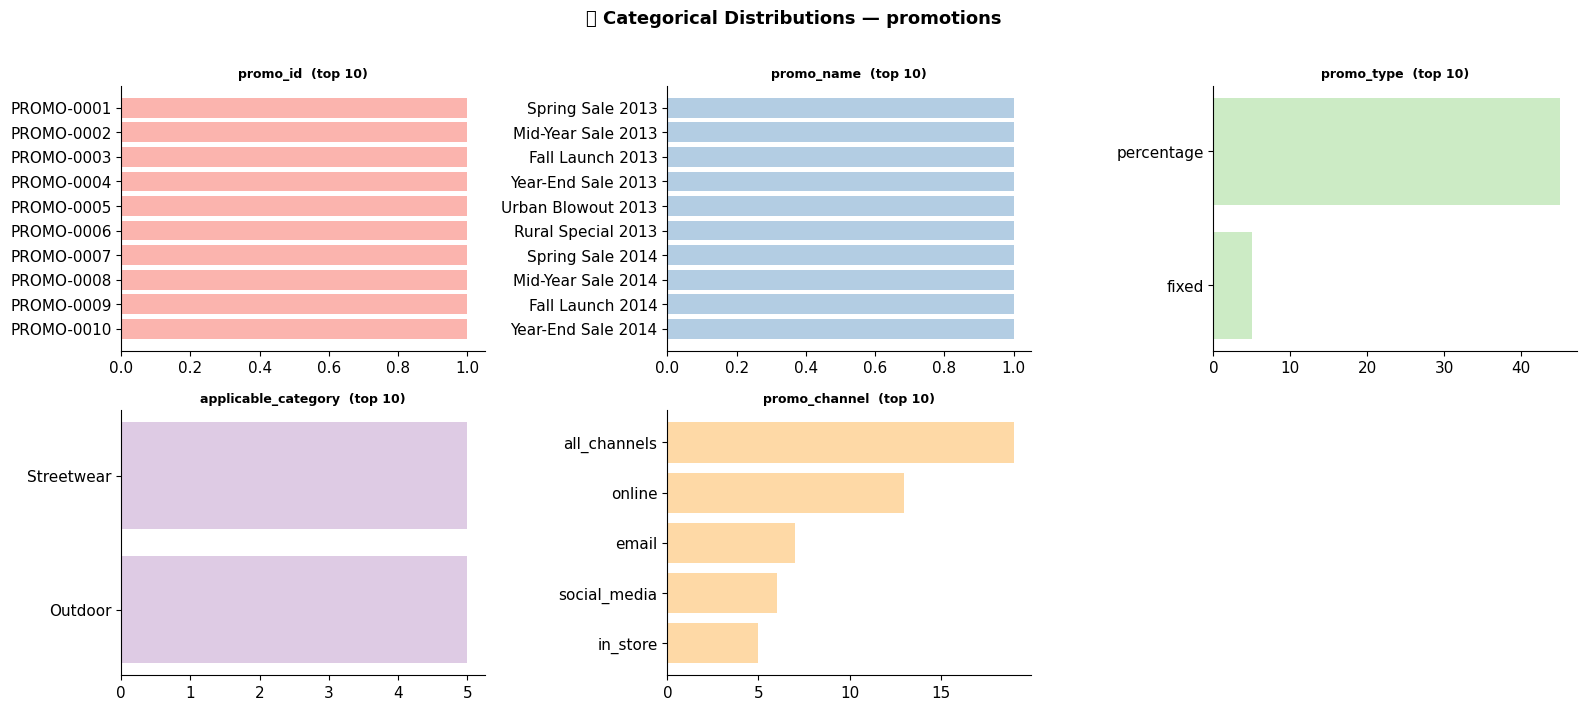

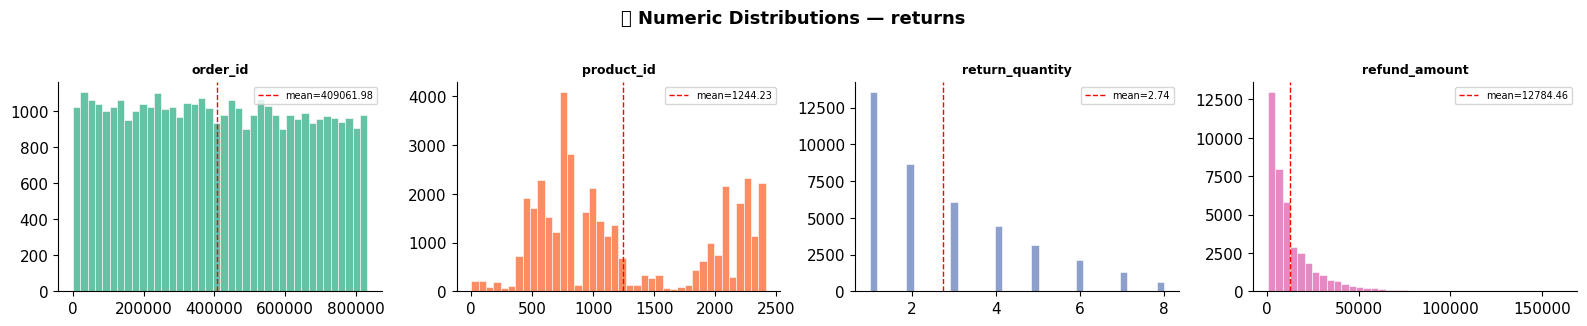

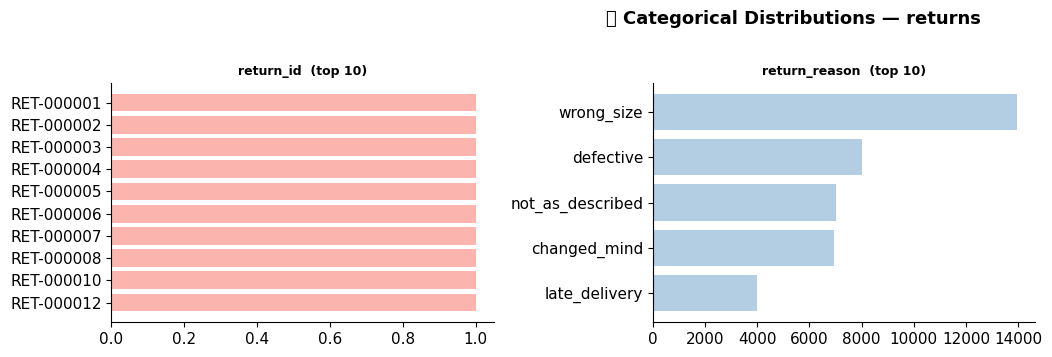

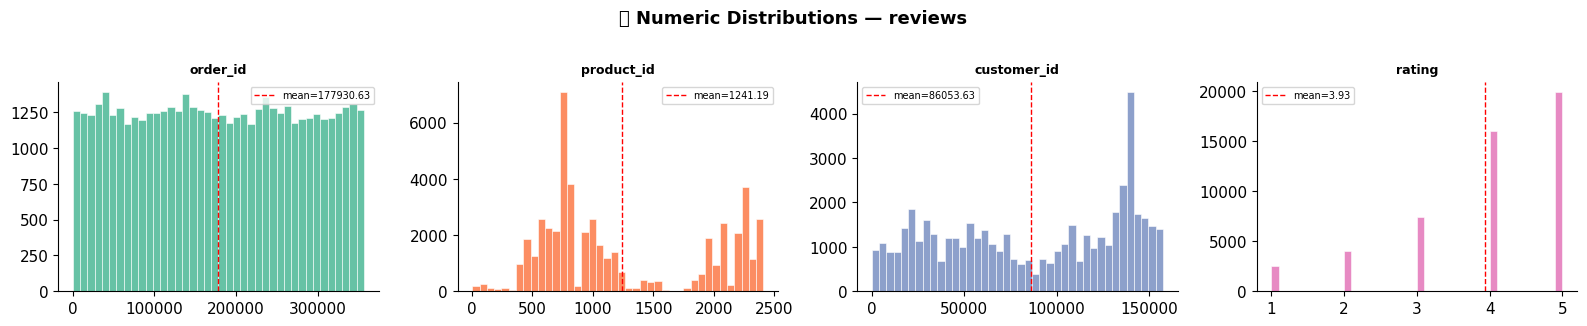

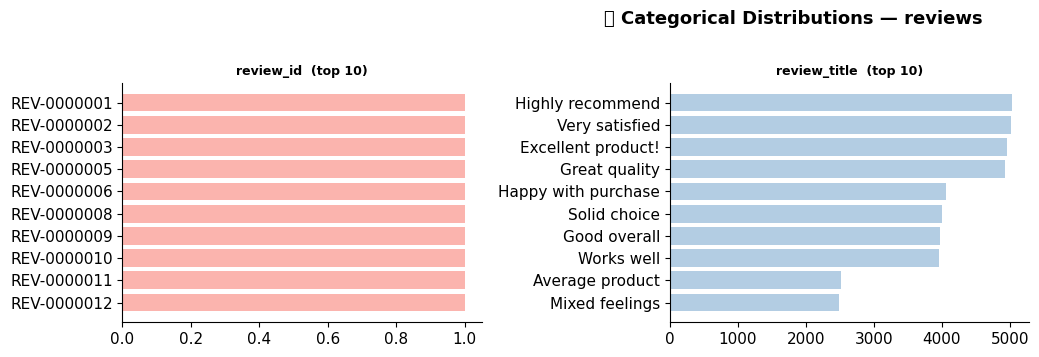

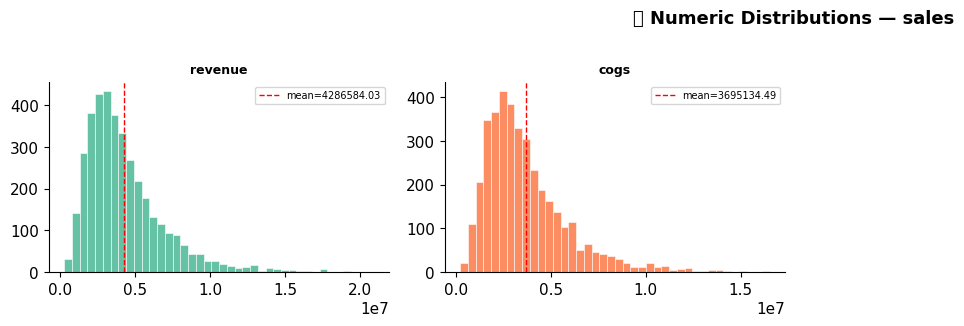

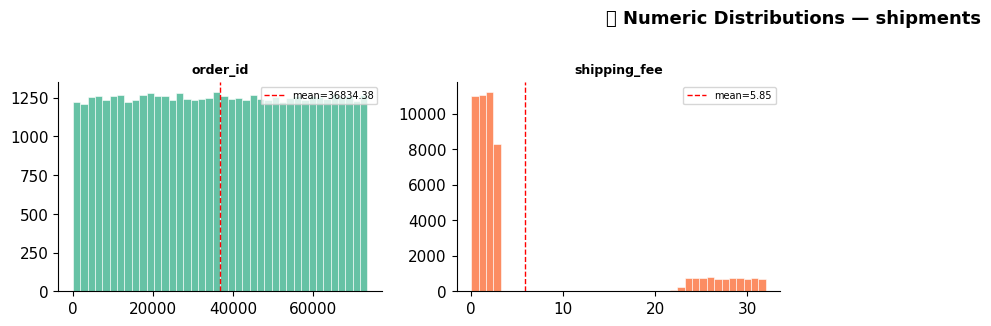

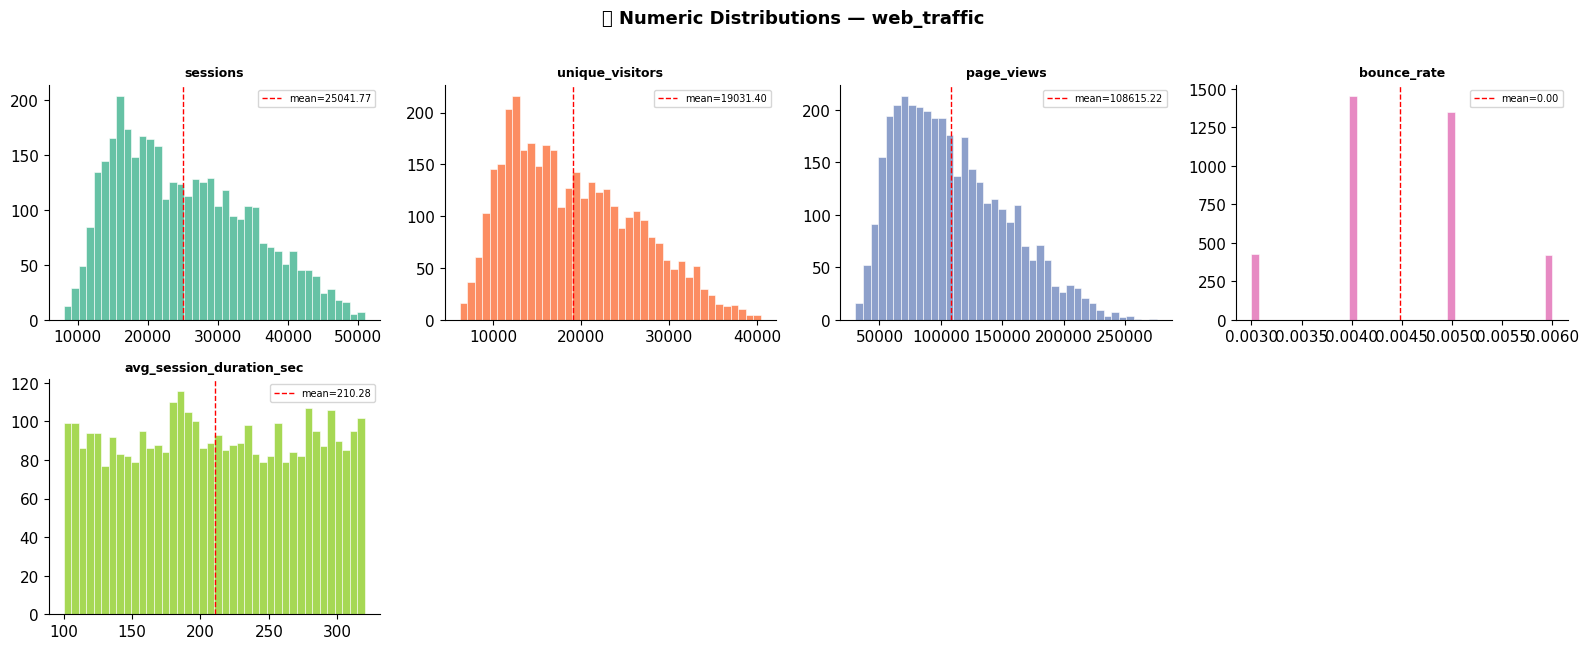

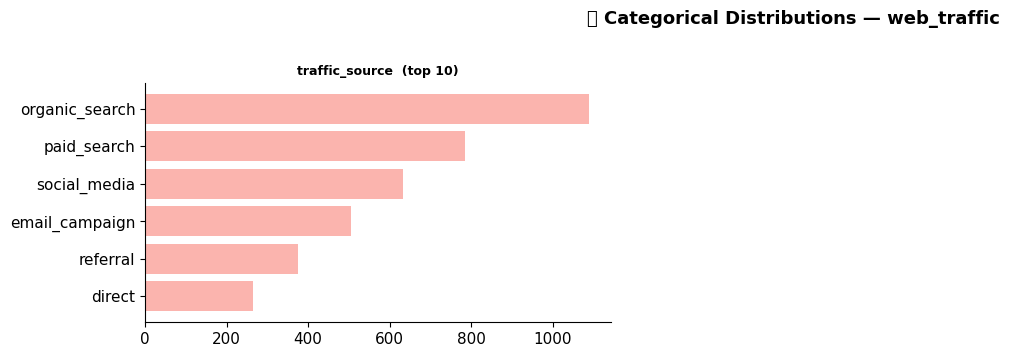

In [17]:
# ── Hàm vẽ phân phối 1 bảng ──────────────────────────────────────────────
def plot_distributions(tbl_name: str, max_cols: int = 12):
    df = table_stats[tbl_name]['df']
    num_cols = df.select_dtypes(include='number').columns.tolist()[:max_cols]
    cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()[:6]

    # --- Numeric distributions ---
    if num_cols:
        ncols = 4
        nrows = (len(num_cols) + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.2))
        axes = axes.flatten()

        for i, col in enumerate(num_cols):
            data = df[col].dropna()
            axes[i].hist(data, bins=40, color=sns.color_palette('Set2')[i % 8],
                        edgecolor='white', linewidth=0.4)
            axes[i].set_title(f'{col}', fontsize=9, fontweight='bold')
            axes[i].set_xlabel('')
            # Thêm thống kê nhỏ
            mu, sigma = data.mean(), data.std()
            axes[i].axvline(mu, color='red', linestyle='--', linewidth=1, label=f'mean={mu:.2f}')
            axes[i].legend(fontsize=7)

        for j in range(len(num_cols), len(axes)):
            axes[j].set_visible(False)

        fig.suptitle(f'📊 Numeric Distributions — {tbl_name}', fontsize=13, fontweight='bold', y=1.01)
        plt.tight_layout()
        plt.show()

    # --- Categorical top-N ---
    if cat_cols:
        ncols = 3
        nrows = (len(cat_cols) + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
        axes = axes.flatten()

        for i, col in enumerate(cat_cols):
            top = df[col].value_counts().head(10)
            axes[i].barh(top.index.astype(str), top.values,
                         color=sns.color_palette('Pastel1')[i % 9])
            axes[i].set_title(f'{col}  (top 10)', fontsize=9, fontweight='bold')
            axes[i].invert_yaxis()

        for j in range(len(cat_cols), len(axes)):
            axes[j].set_visible(False)

        fig.suptitle(f'🏷️ Categorical Distributions — {tbl_name}', fontsize=13, fontweight='bold', y=1.01)
        plt.tight_layout()
        plt.show()

# Chạy cho tất cả bảng
for tbl in TABLES:
    plot_distributions(tbl)

---
## 6. Phát hiện Outlier (IQR Method)

In [18]:
# ── Outlier summary tổng hợp ─────────────────────────────────────────────
def detect_outliers_iqr(df: pd.DataFrame) -> pd.DataFrame:
    records = []
    for col in df.select_dtypes(include='number').columns:
        data = df[col].dropna()
        if len(data) < 10:
            continue
        Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
        IQR = Q3 - Q1
        lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        n_out = ((data < lo) | (data > hi)).sum()
        records.append({
            'column': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
            'lower_fence': lo, 'upper_fence': hi,
            'outlier_count': n_out,
            'outlier_pct': round(n_out / len(data) * 100, 2)
        })
    return pd.DataFrame(records).sort_values('outlier_pct', ascending=False)


all_outliers = {}
for tbl, stats in table_stats.items():
    o = detect_outliers_iqr(stats['df'])
    if not o.empty:
        all_outliers[tbl] = o

# Tổng hợp
outlier_summary = pd.concat(
    [df.assign(table=tbl) for tbl, df in all_outliers.items()],
    ignore_index=True
)[['table', 'column', 'outlier_count', 'outlier_pct']]

print('⚠️  Outlier Summary (IQR):')
display(
    outlier_summary[outlier_summary['outlier_pct'] > 0]
    .sort_values('outlier_pct', ascending=False)
    .head(30)
    .style.background_gradient(subset=['outlier_pct'], cmap='YlOrRd')
)

⚠️  Outlier Summary (IQR):


,table,column,outlier_count,outlier_pct
30,promotions,stackable_flag,12,24.000000
43,shipments,shipping_fee,8451,16.900000
3,inventory,days_of_supply,6202,12.400000
4,inventory,stock_on_hand,5964,11.930000
5,inventory,units_received,5711,11.420000
6,inventory,units_sold,5482,10.960000
31,promotions,discount_value,5,10.000000
33,returns,refund_amount,2778,6.960000
16,order_items,discount_amount,3306,6.610000
24,payments,payment_value,2741,5.480000


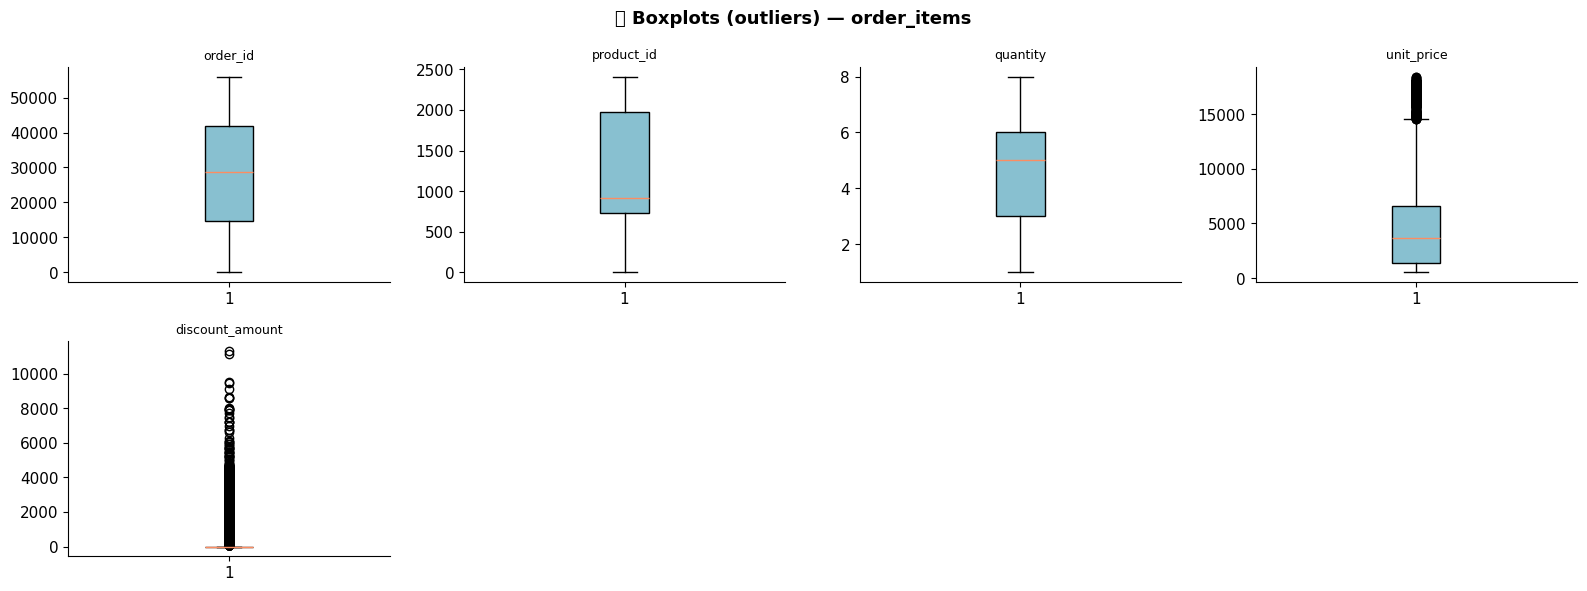

In [19]:
# ── Boxplot outlier cho bảng lớn nhất ────────────────────────────────────
biggest_tbl = max(row_counts, key=lambda k: row_counts.get(k, 0))
df_big = table_stats[biggest_tbl]['df']
num_cols = df_big.select_dtypes(include='number').columns.tolist()[:8]

if num_cols:
    fig, axes = plt.subplots(2, 4, figsize=(16, 6))
    axes = axes.flatten()
    for i, col in enumerate(num_cols[:8]):
        axes[i].boxplot(df_big[col].dropna(), vert=True, patch_artist=True,
                        boxprops=dict(facecolor='#88c0d0'))
        axes[i].set_title(col, fontsize=9)
    for j in range(len(num_cols), 8):
        axes[j].set_visible(False)
    fig.suptitle(f'📦 Boxplots (outliers) — {biggest_tbl}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 7. Correlation Analysis (per table)

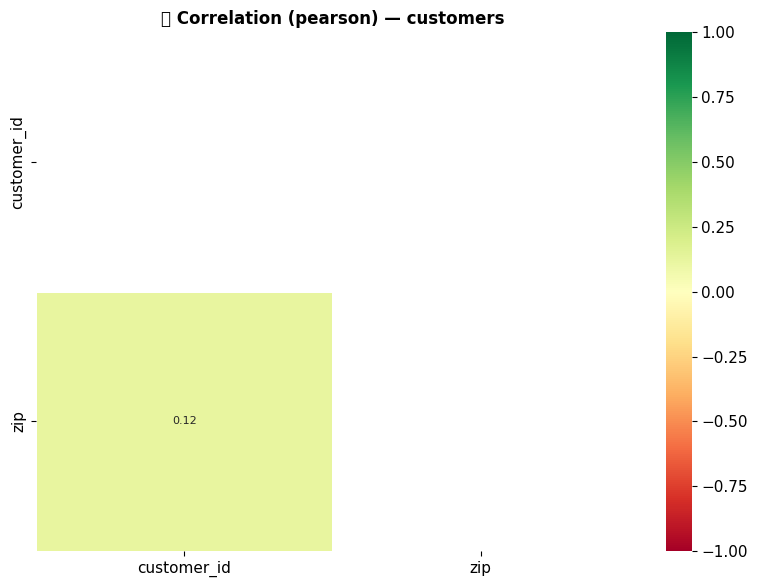

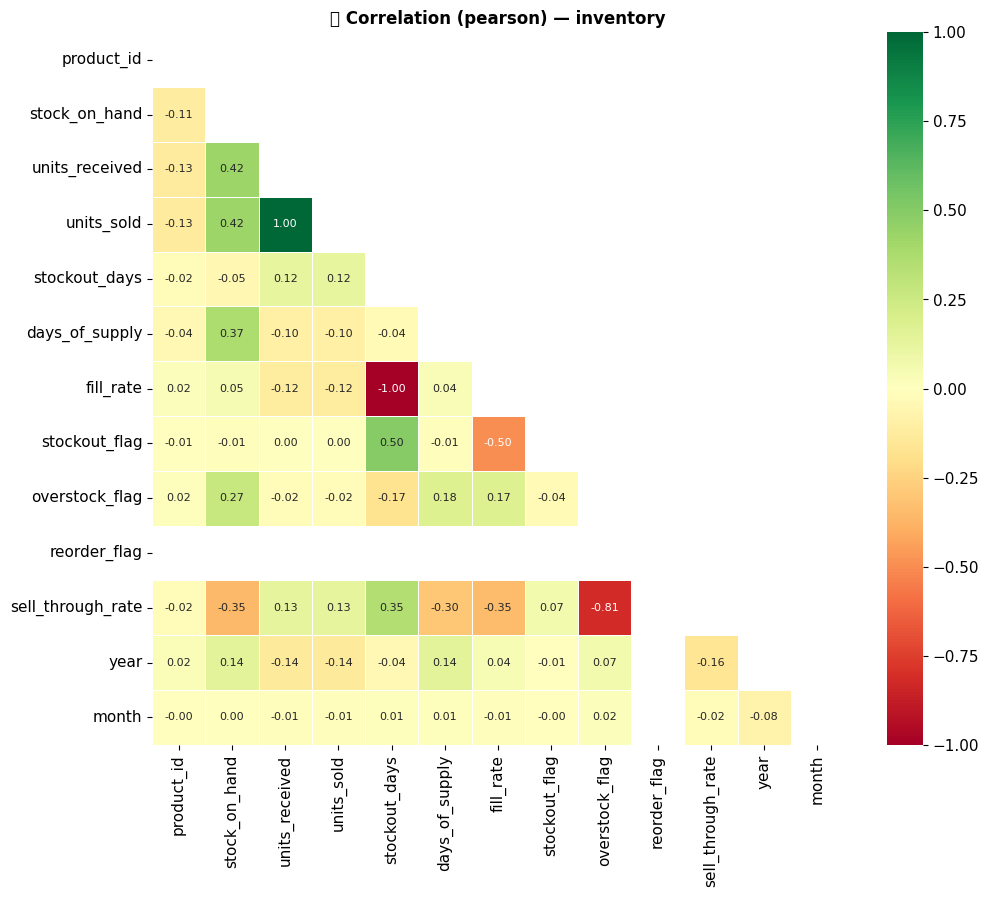

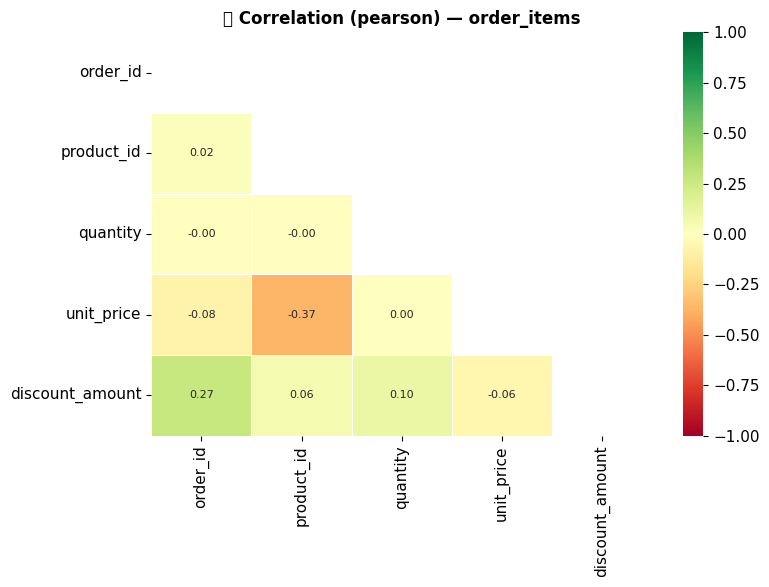

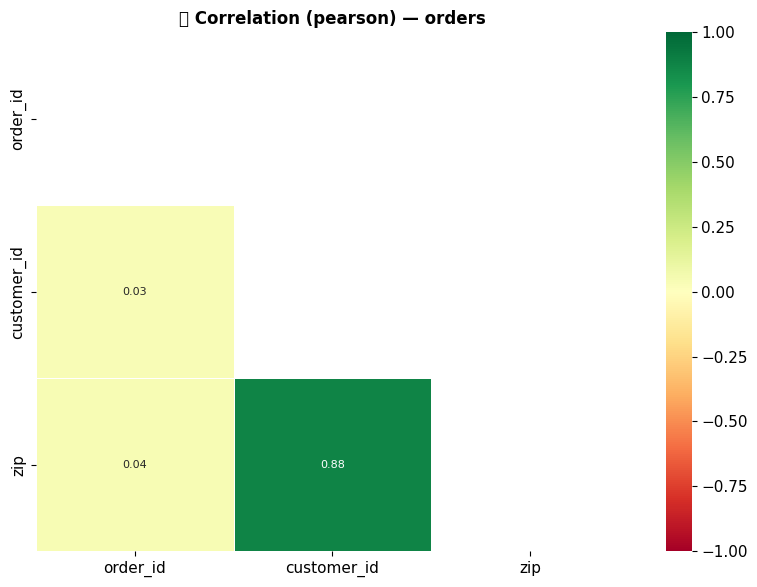

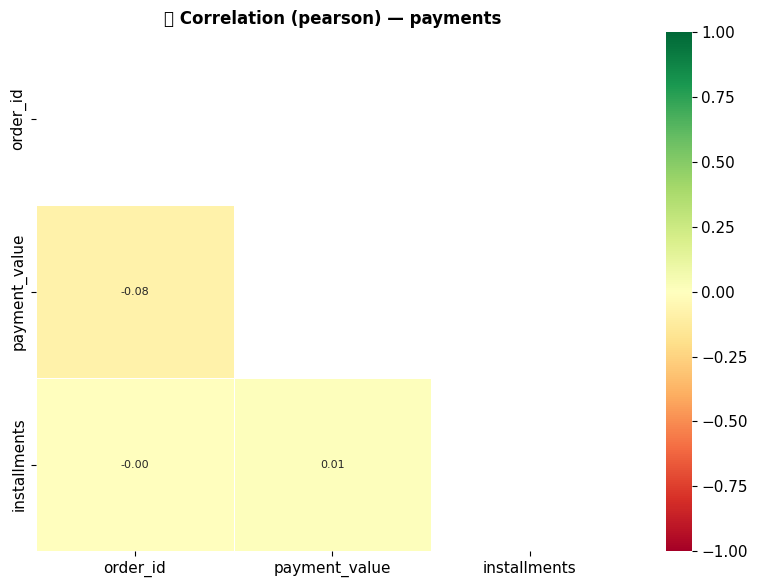

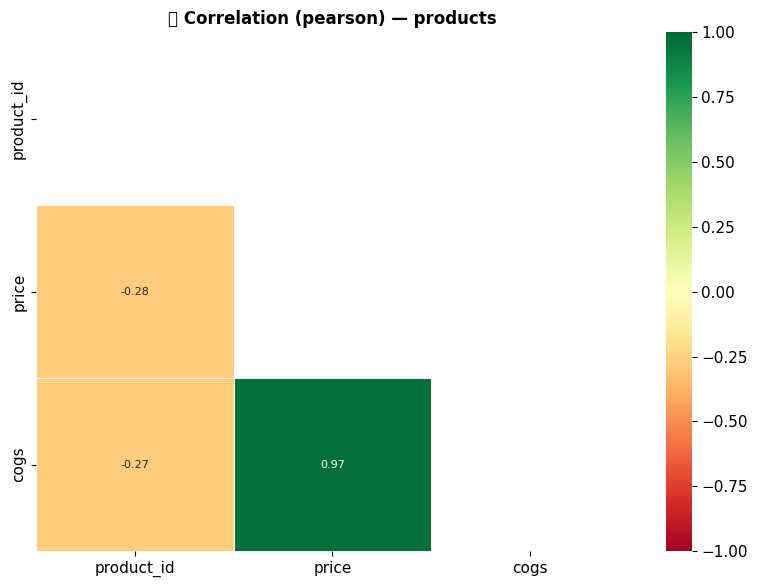

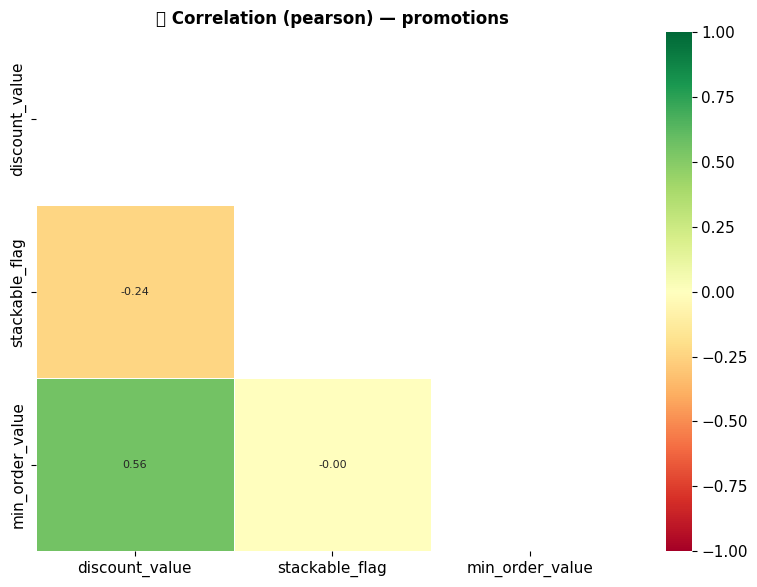

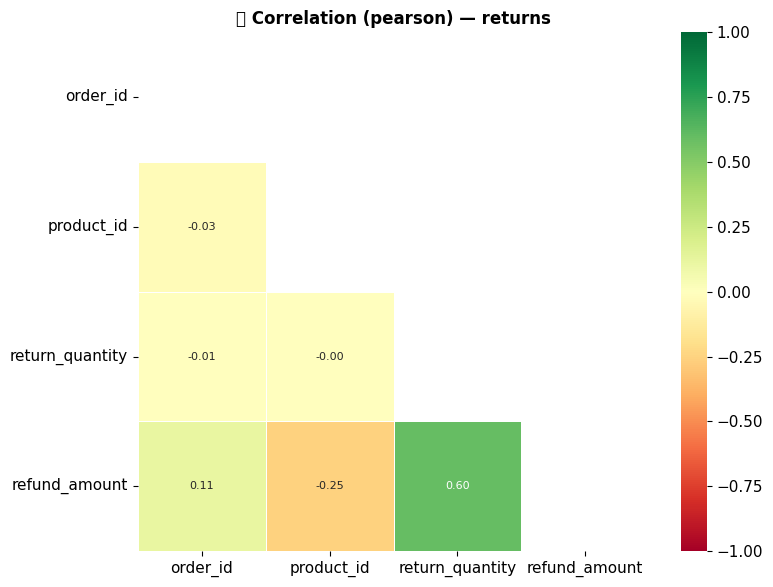

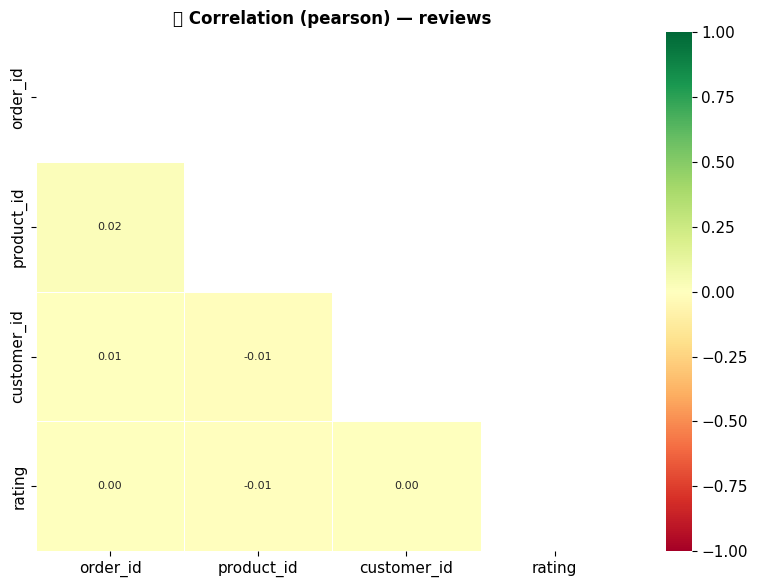

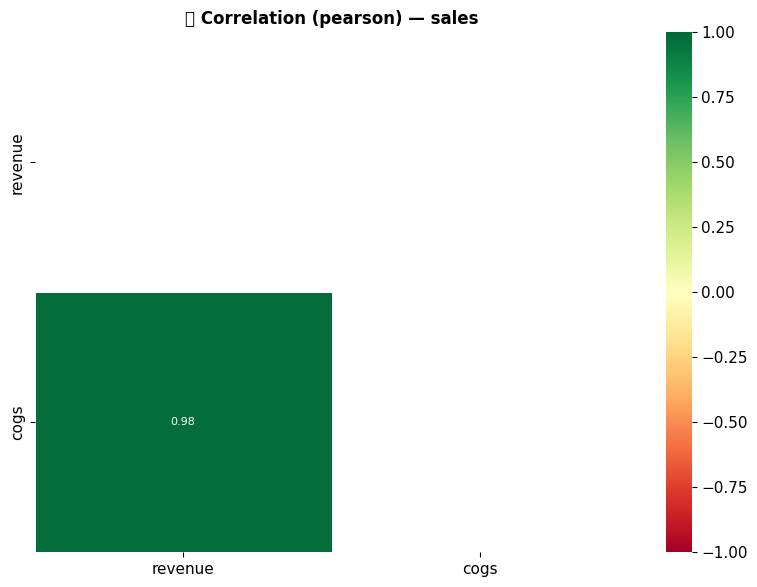

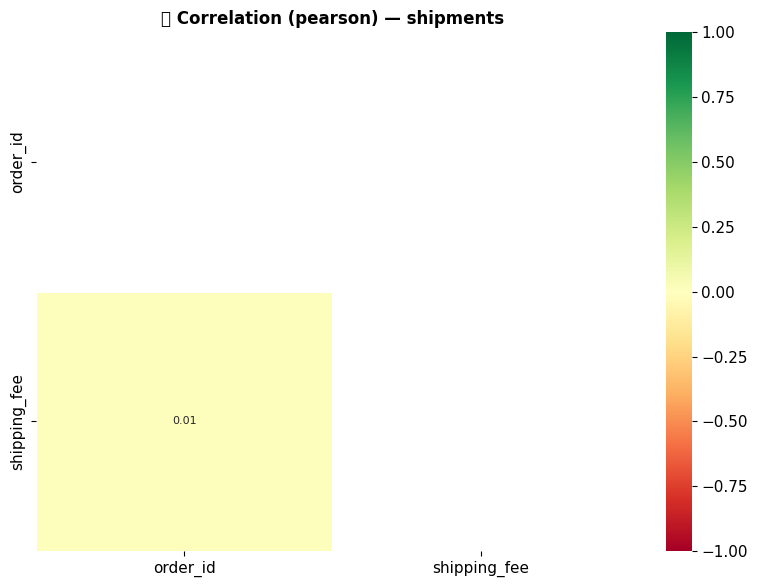

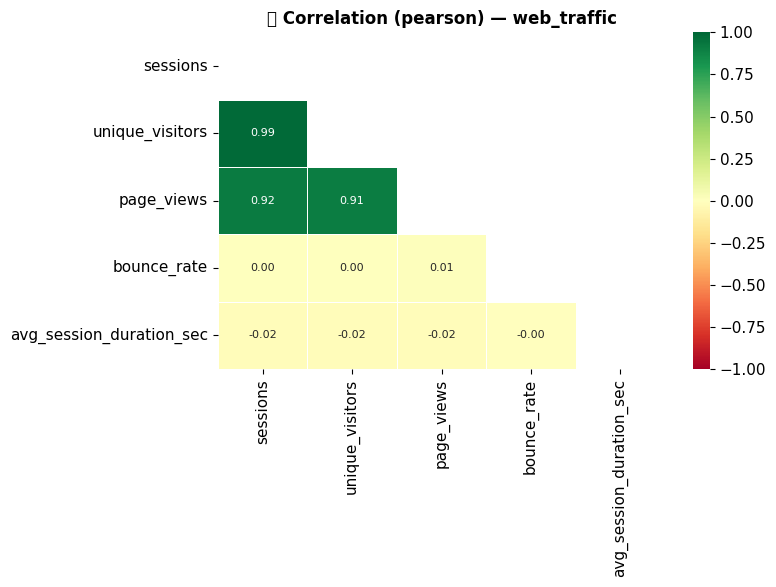

In [20]:
# ── Correlation heatmap cho từng bảng ────────────────────────────────────
def plot_correlation(tbl_name: str, method: str = 'pearson'):
    df = table_stats[tbl_name]['df']
    num = df.select_dtypes(include='number')
    if num.shape[1] < 2:
        return

    corr = num.corr(method=method)

    mask = np.triu(np.ones_like(corr, dtype=bool))
    fig, ax = plt.subplots(figsize=(max(8, corr.shape[1] * 0.8), max(6, corr.shape[0] * 0.7)))
    sns.heatmap(
        corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
        center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
        annot_kws={'size': 8}
    )
    ax.set_title(f'🔗 Correlation ({method}) — {tbl_name}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


for tbl in TABLES:
    plot_correlation(tbl)

---
## 8. Phân tích Mối Quan Hệ Giữa Các Bảng (Foreign Key Integrity)

In [21]:
# ── Lấy foreign key constraints (DuckDB / Postgres-compatible) ───────────
# ⚠️  Thay bằng query phù hợp với engine của bạn nếu cần
try:
    fk_df = q("""
        SELECT
            kcu.table_name     AS child_table,
            kcu.column_name    AS child_column,
            ccu.table_name     AS parent_table,
            ccu.column_name    AS parent_column,
            tc.constraint_name
        FROM information_schema.table_constraints AS tc
        JOIN information_schema.key_column_usage AS kcu
            ON tc.constraint_name = kcu.constraint_name
        JOIN information_schema.constraint_column_usage AS ccu
            ON ccu.constraint_name = tc.constraint_name
        WHERE tc.constraint_type = 'FOREIGN KEY'
        ORDER BY child_table, child_column
    """)
    print(f'🔗 Found {len(fk_df)} foreign key relationships:')
    display(fk_df)
except Exception as e:
    print(f'ℹ️  Could not query FK constraints automatically: {e}')
    print('   → Định nghĩa thủ công FOREIGN_KEYS bên dưới.')
    fk_df = pd.DataFrame(columns=['child_table','child_column','parent_table','parent_column'])

🔗 Found 15 foreign key relationships:


,child_table,child_column,parent_table,parent_column,constraint_name
0,customers,zip,customers,zip,customers_zip_zip_fkey
1,inventory,product_id,inventory,product_id,inventory_product_id_product_id_fkey
2,order_items,order_id,order_items,order_id,order_items_order_id_order_id_fkey
3,order_items,product_id,order_items,product_id,order_items_product_id_product_id_fkey
4,order_items,promo_id,order_items,promo_id,order_items_promo_id_promo_id_fkey
5,order_items,promo_id_2,order_items,promo_id_2,order_items_promo_id_2_promo_id_fkey
6,orders,customer_id,orders,customer_id,orders_customer_id_customer_id_fkey
7,orders,zip,orders,zip,orders_zip_zip_fkey
8,payments,order_id,payments,order_id,payments_order_id_order_id_fkey
9,returns,order_id,returns,order_id,returns_order_id_order_id_fkey


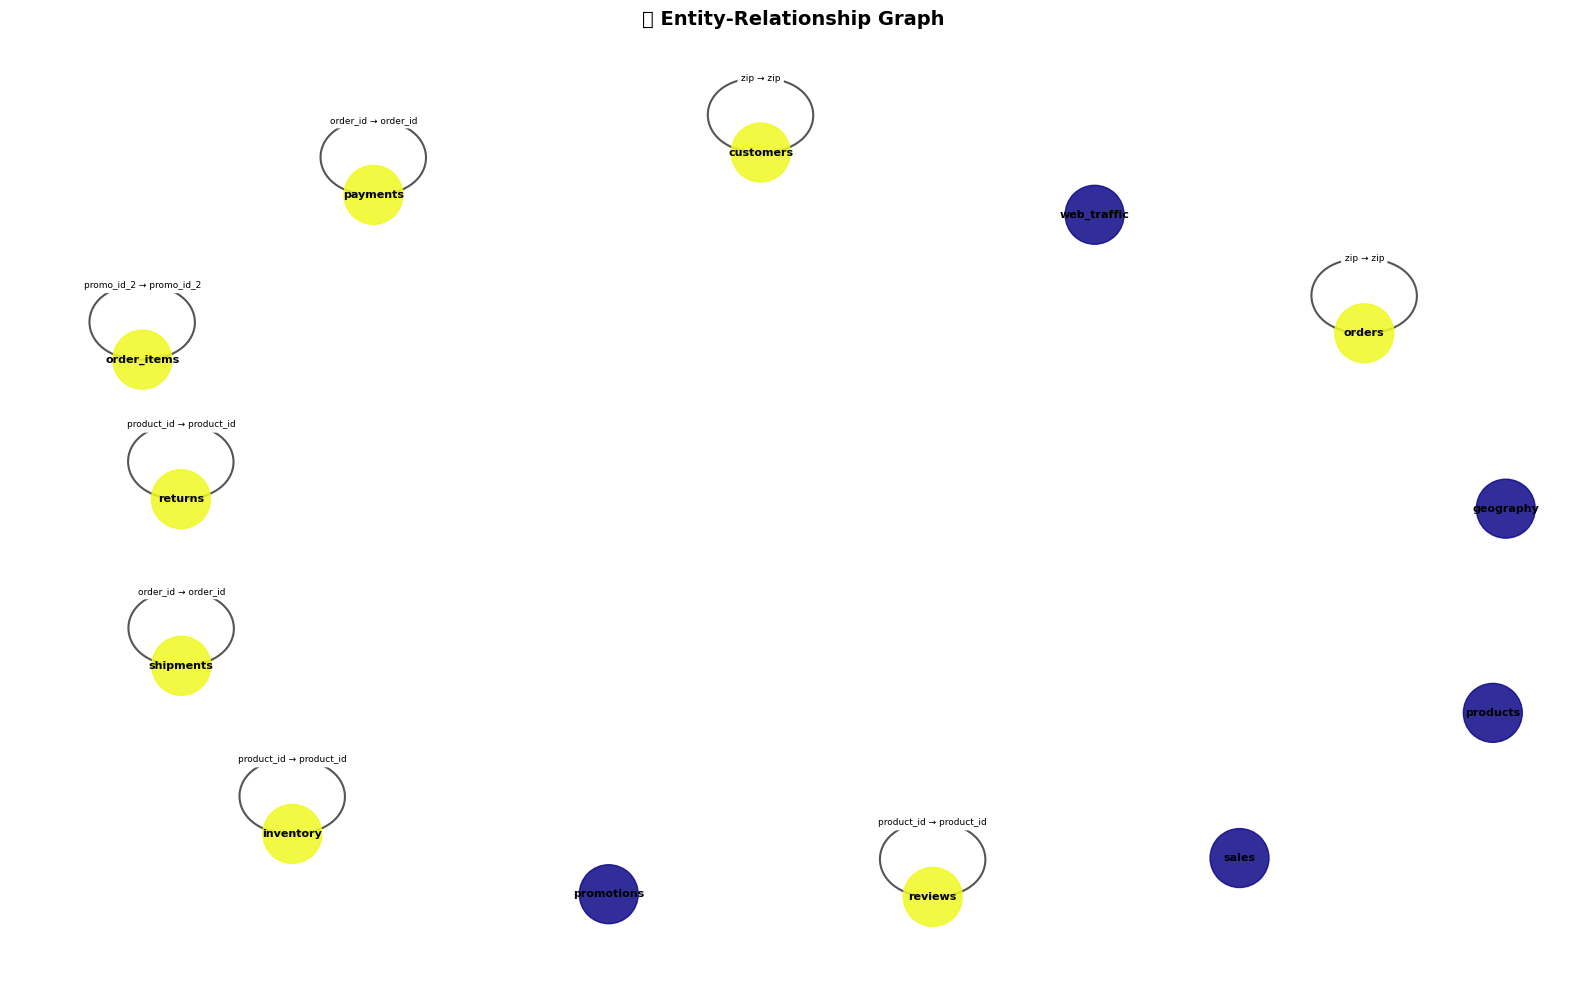

In [22]:
# ── Vẽ Entity-Relationship Graph ─────────────────────────────────────────
if not fk_df.empty:
    G = nx.DiGraph()
    G.add_nodes_from(TABLES)

    for _, row in fk_df.iterrows():
        G.add_edge(
            row['child_table'], row['parent_table'],
            label=f"{row['child_column']} → {row['parent_column']}"
        )

    fig, ax = plt.subplots(figsize=(16, 10))
    pos = nx.spring_layout(G, k=2.5, seed=42)

    # Màu node theo số kết nối
    degree = dict(G.degree())
    node_colors = [plt.cm.plasma(degree[n] / max(degree.values() or [1])) for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, node_size=1800, node_color=node_colors, alpha=0.85, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)
    nx.draw_networkx_edges(G, pos, arrowsize=18, edge_color='#555', width=1.5,
                           connectionstyle='arc3,rad=0.1', ax=ax)
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=6.5, ax=ax)

    ax.set_title('🗺️ Entity-Relationship Graph', fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('ℹ️  Không có FK data để vẽ ERD. Hãy định nghĩa FOREIGN_KEYS thủ công ở cell trên.')

In [23]:
# ── Kiểm tra FK Integrity (orphan records) ───────────────────────────────
integrity_results = []

for _, fk in fk_df.iterrows():
    child, cc, parent, pc = fk['child_table'], fk['child_column'], fk['parent_table'], fk['parent_column']
    try:
        sql = f"""
            SELECT COUNT(*) AS orphans
            FROM "{child}" c
            LEFT JOIN "{parent}" p ON c."{cc}" = p."{pc}"
            WHERE c."{cc}" IS NOT NULL AND p."{pc}" IS NULL
        """
        orphans = q(sql)['orphans'].iloc[0]
        integrity_results.append({
            'child_table': child, 'child_column': cc,
            'parent_table': parent, 'parent_column': pc,
            'orphan_records': orphans,
            'integrity_ok': orphans == 0
        })
    except Exception as e:
        integrity_results.append({
            'child_table': child, 'child_column': cc,
            'parent_table': parent, 'parent_column': pc,
            'orphan_records': f'ERROR: {e}',
            'integrity_ok': None
        })

if integrity_results:
    int_df = pd.DataFrame(integrity_results)
    print('🔍 Foreign Key Integrity Check:')
    display(
        int_df.style.apply(
            lambda col: ['background: #d4edda' if v else 'background: #f8d7da'
                         for v in col] if col.name == 'integrity_ok' else [''] * len(col),
            axis=0
        )
    )

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

🔍 Foreign Key Integrity Check:


,child_table,child_column,parent_table,parent_column,orphan_records,integrity_ok
0,customers,zip,customers,zip,0,True
1,inventory,product_id,inventory,product_id,0,True
2,order_items,order_id,order_items,order_id,0,True
3,order_items,product_id,order_items,product_id,0,True
4,order_items,promo_id,order_items,promo_id,0,True
5,order_items,promo_id_2,order_items,promo_id_2,0,True
6,orders,customer_id,orders,customer_id,0,True
7,orders,zip,orders,zip,0,True
8,payments,order_id,payments,order_id,0,True
9,returns,order_id,returns,order_id,0,True


---
## 9. Cross-Table Join Analysis

In [24]:
# ── Tỷ lệ match khi join 2 bảng ──────────────────────────────────────────
# Tự động chạy theo FK đã định nghĩa

join_stats = []
for _, fk in fk_df.iterrows():
    child, cc, parent, pc = fk['child_table'], fk['child_column'], fk['parent_table'], fk['parent_column']
    try:
        sql = f"""
            SELECT
                COUNT(*) AS total_child,
                SUM(CASE WHEN p."{pc}" IS NOT NULL THEN 1 ELSE 0 END) AS matched,
                SUM(CASE WHEN p."{pc}" IS NULL THEN 1 ELSE 0 END) AS unmatched
            FROM "{child}" c
            LEFT JOIN "{parent}" p ON c."{cc}" = p."{pc}"
        """
        res = q(sql).iloc[0]
        join_stats.append({
            'join': f'{child} → {parent}',
            'total_child': res['total_child'],
            'matched': res['matched'],
            'unmatched': res['unmatched'],
            'match_pct': round(res['matched'] / max(res['total_child'], 1) * 100, 2)
        })
    except Exception as e:
        join_stats.append({'join': f'{child} → {parent}', 'error': str(e)})

if join_stats:
    js_df = pd.DataFrame(join_stats)
    print('🔗 Join Match Rate:')
    display(js_df.style.background_gradient(subset=['match_pct'], cmap='RdYlGn'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

🔗 Join Match Rate:


,join,total_child,matched,unmatched,match_pct
0,customers → customers,499272.000000,499272.000000,0.000000,100.000000
1,inventory → inventory,4022317.000000,4022317.000000,0.000000,100.000000
2,order_items → order_items,852787.000000,852787.000000,0.000000,100.000000
3,order_items → order_items,1929289117.000000,1929289117.000000,0.000000,100.000000
4,order_items → order_items,1912174453.000000,1911736100.000000,438353.000000,99.980000
5,order_items → order_items,737363.000000,22900.000000,714463.000000,3.110000
6,orders → orders,11358373.000000,11358373.000000,0.000000,100.000000
7,orders → orders,44945823.000000,44945823.000000,0.000000,100.000000
8,payments → payments,646945.000000,646945.000000,0.000000,100.000000
9,returns → returns,47845.000000,47845.000000,0.000000,100.000000


---
## 10. Time Series Analysis (nếu có cột datetime)

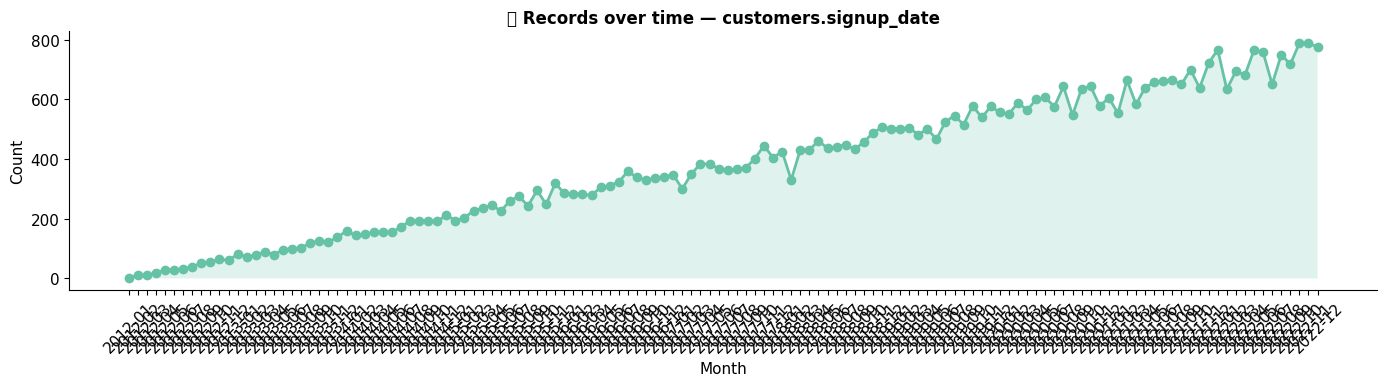

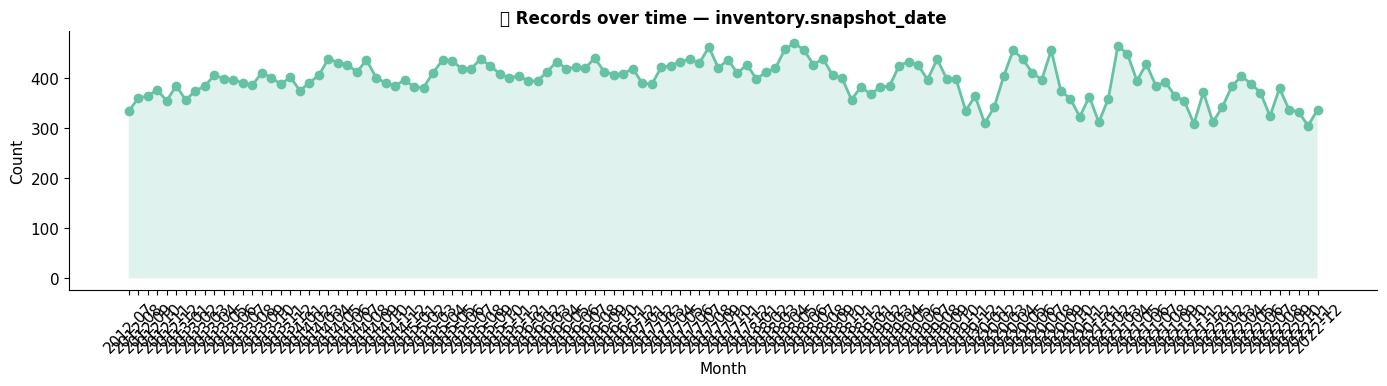

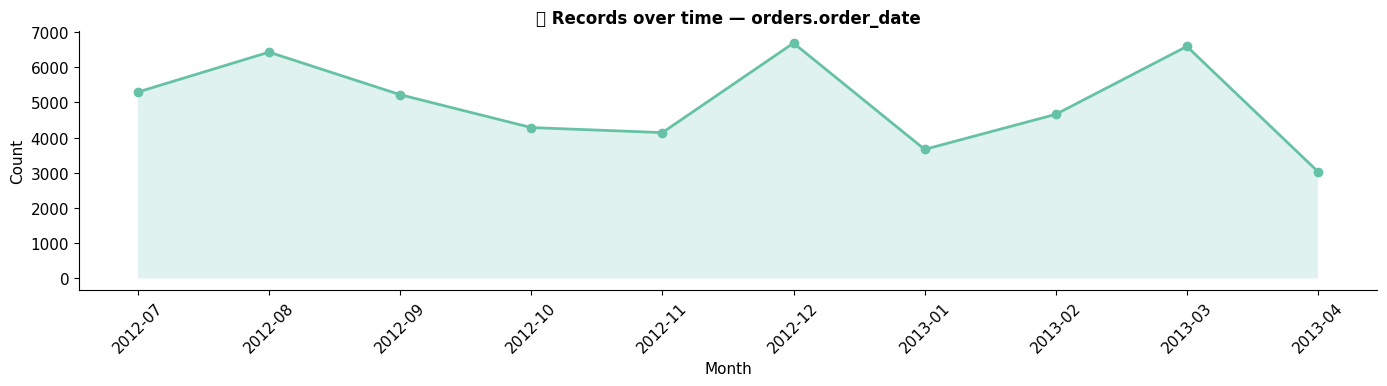

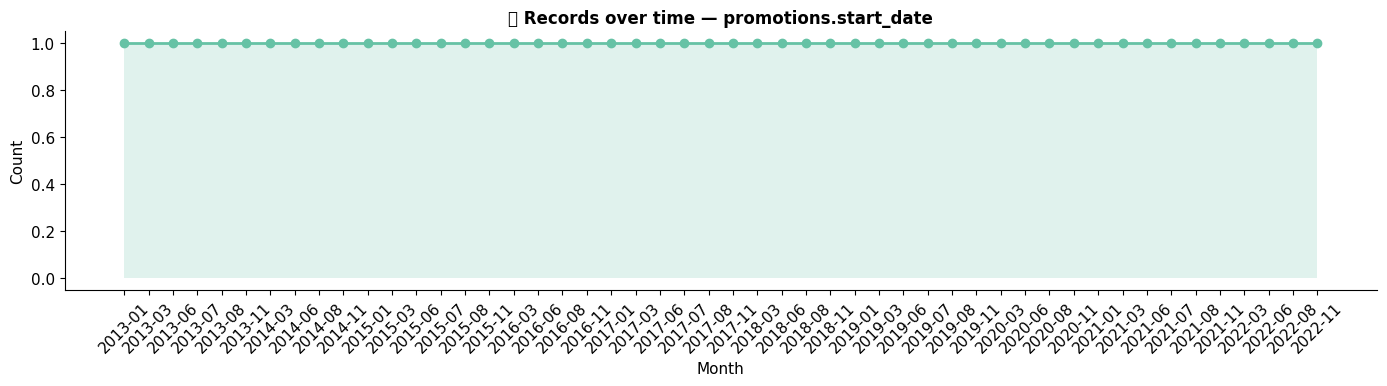

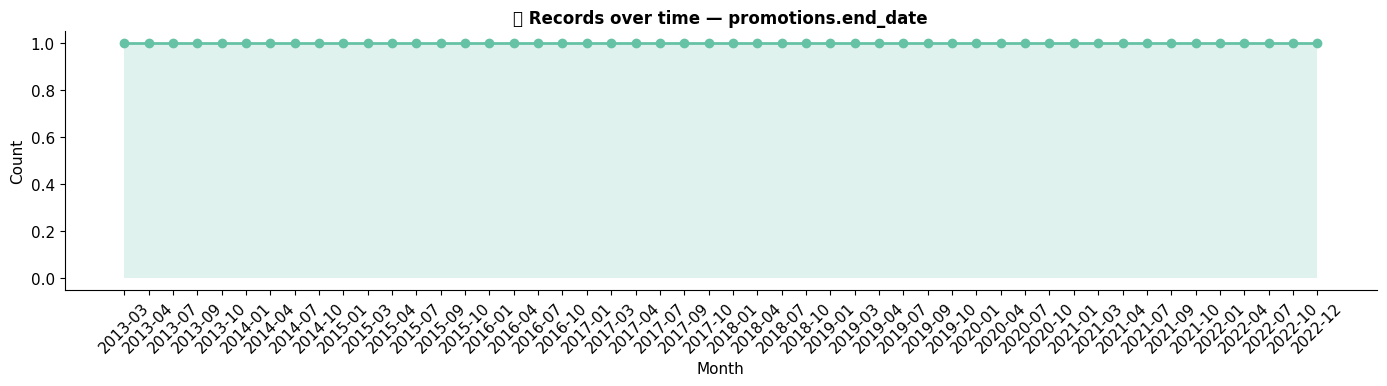

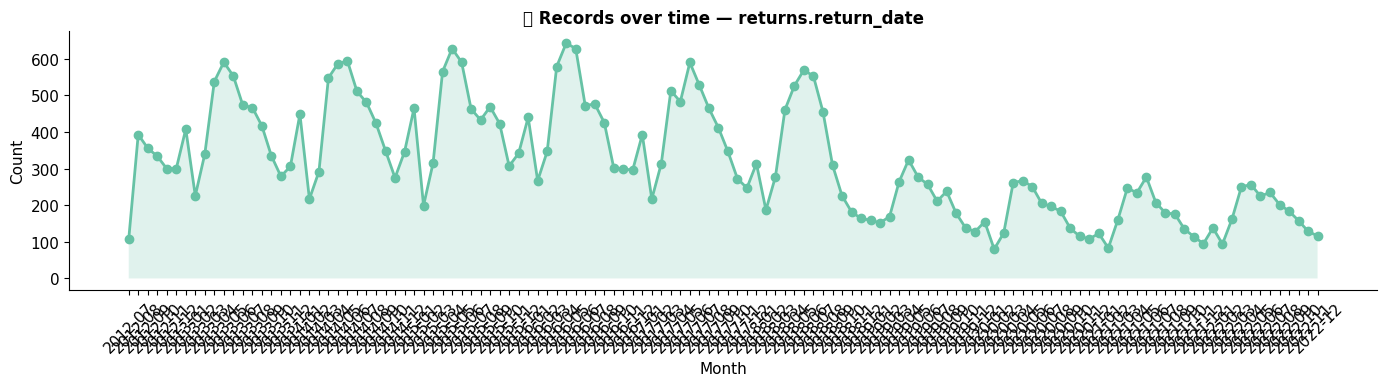

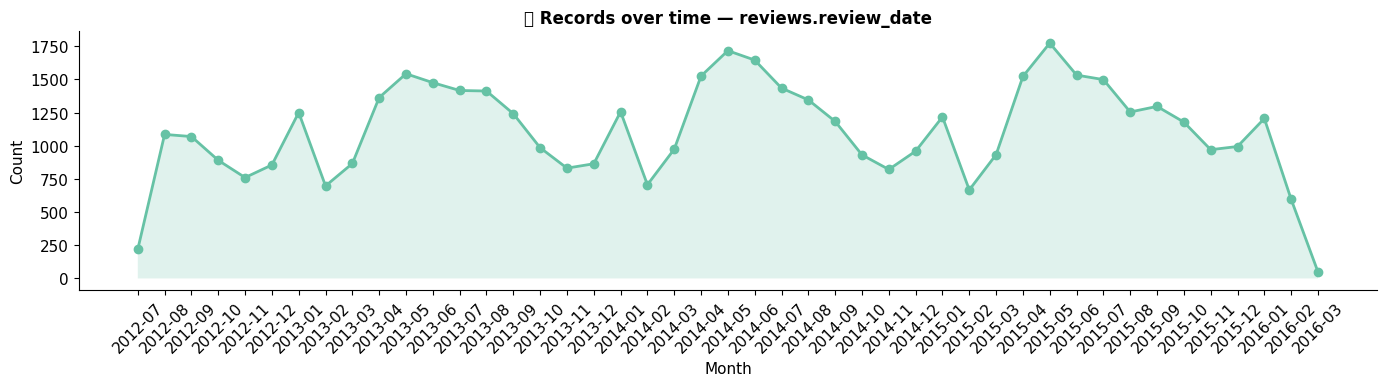

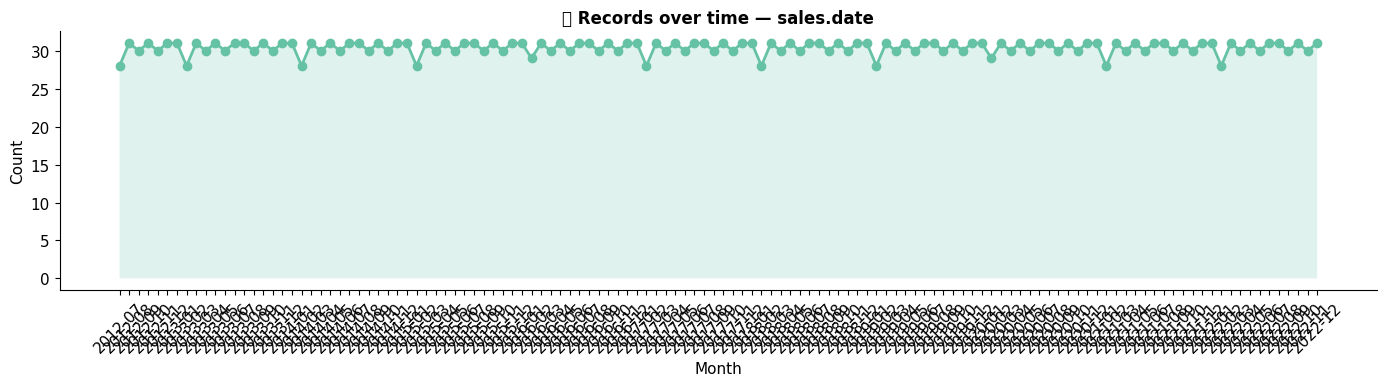

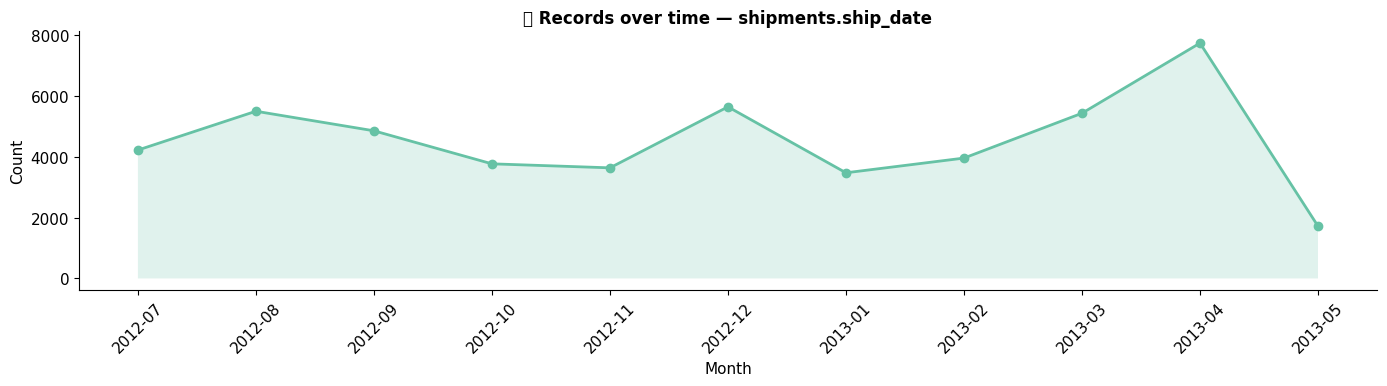

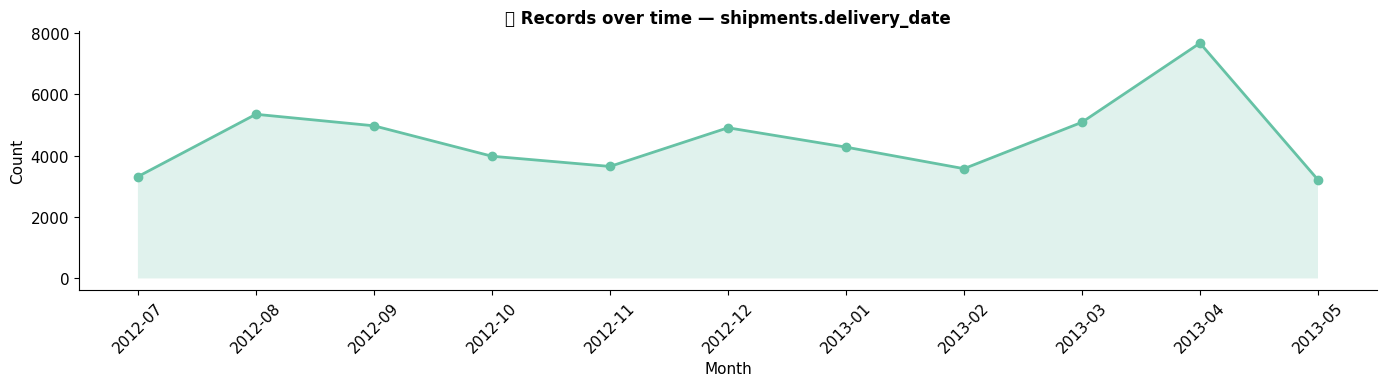

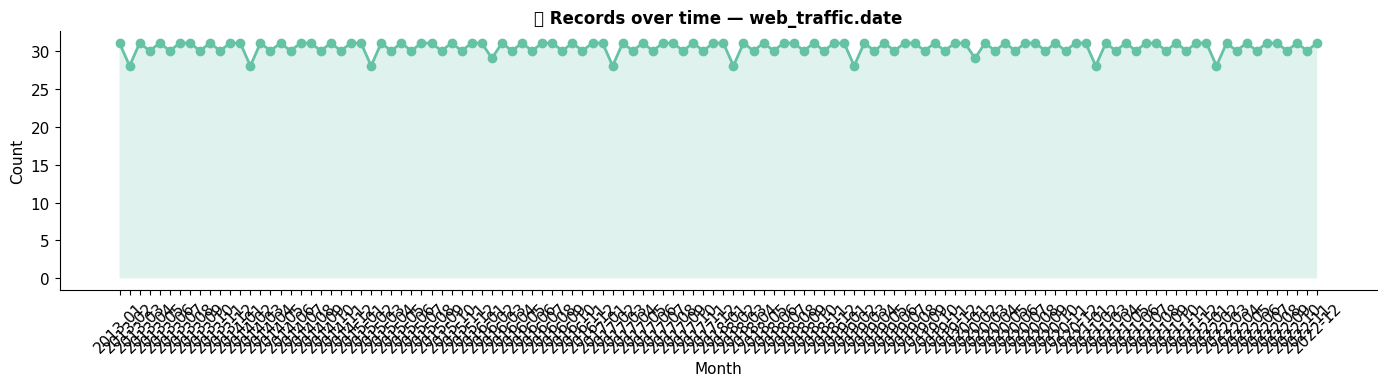

In [25]:
# ── Tìm & vẽ time series cho các cột date/datetime ───────────────────────
for tbl, stats in table_stats.items():
    df = stats['df']
    date_cols = df.select_dtypes(include=['datetime64', 'datetime', 'datetimetz']).columns.tolist()

    # Heuristic: tìm thêm cột tên có 'date', 'time', 'at', 'created', 'updated'
    for col in df.columns:
        if col not in date_cols and any(kw in col.lower() for kw in ['date', 'time', '_at', 'created', 'updated']):
            try:
                df[col] = pd.to_datetime(df[col], errors='coerce')
                if df[col].notna().sum() > 10:
                    date_cols.append(col)
            except:
                pass

    for dcol in date_cols[:2]:  # max 2 date cols per table
        try:
            ts = df[dcol].dropna().dt.to_period('M').value_counts().sort_index()
            if len(ts) < 2:
                continue
            fig, ax = plt.subplots(figsize=(14, 4))
            ax.plot(ts.index.astype(str), ts.values, marker='o', linewidth=2)
            ax.fill_between(ts.index.astype(str), ts.values, alpha=0.2)
            ax.set_title(f'📅 Records over time — {tbl}.{dcol}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Month')
            ax.set_ylabel('Count')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f'  ⚠️  {tbl}.{dcol}: {e}')

---
## 11. EDA Summary Dashboard

In [ ]:
# ── Tổng hợp EDA cuối cùng ───────────────────────────────────────────────
total_rows = sum(v for v in row_counts.values() if v > 0)
total_cols = sum(len(s['df'].columns) for s in table_stats.values())
avg_null = np.mean([s['null_report']['null_pct'].mean() for s in table_stats.values()])
total_dup = sum(s['dup_count'] for s in table_stats.values())
n_fk = len(fk_df)

summary = pd.DataFrame({
    'Metric': [
        '📦 Total Tables', '📋 Total Columns', '🗂️ Total Rows',
        '🚨 Avg Null %', '🔁 Total Duplicates', '🔗 FK Relationships'
    ],
    'Value': [
        len(TABLES), total_cols, f'{total_rows:,}',
        f'{avg_null:.1f}%', f'{total_dup:,}', n_fk
    ]
})

display(HTML('<h2 style="color:#2c3e50">📋 EDA Summary Dashboard</h2>'))
display(summary.style.set_properties(**{'font-size': '14px', 'text-align': 'left'}))

# Heatmap: row count vs column count
fig = px.scatter(
    x=[row_counts.get(t, 0) for t in TABLES],
    y=[len(table_stats[t]['df'].columns) for t in TABLES],
    text=TABLES,
    size=[max(row_counts.get(t, 1), 1) for t in TABLES],
    color=TABLES,
    labels={'x': 'Row Count', 'y': 'Column Count'},
    title='📊 Tables: Size vs Width'
)
fig.update_traces(textposition='top center')
fig.show()

In [ ]:
# ── Danh sách cảnh báo chất lượng dữ liệu ───────────────────────────────
print('\n⚠️  DATA QUALITY WARNINGS\n' + '-'*50)

for tbl, stats in table_stats.items():
    nr = stats['null_report']
    high_null = nr[nr['null_pct'] > 30]
    if not high_null.empty:
        cols_str = ', '.join(high_null['column'].tolist())
        print(f'  🔴 [{tbl}] High null (>30%): {cols_str}')

    if stats['dup_count'] > 0:
        print(f'  🟡 [{tbl}] {stats["dup_count"]:,} duplicate rows')

    no_variety = nr[nr['unique_count'] <= 1]
    if not no_variety.empty:
        cols_str = ', '.join(no_variety['column'].tolist())
        print(f'  🟠 [{tbl}] Constant columns (≤1 unique value): {cols_str}')

if integrity_results:
    bad_fk = [r for r in integrity_results if isinstance(r.get('orphan_records'), (int, float)) and r['orphan_records'] > 0]
    for r in bad_fk:
        print(f'  🔴 FK violation: {r["child_table"]}.{r["child_column"]} → {r["parent_table"]}.{r["parent_column"]}  | orphans: {r["orphan_records"]:,}')

print('\n✅ EDA hoàn tất!')